In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 9.2 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
cd drive/MyDrive/Colab Notebooks/2609_FluorescentClassification/data

/content/drive/MyDrive/Colab Notebooks/2609_FluorescentClassification/data


In [6]:
# pandas print option
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

**Data**

In [7]:
# Data
df = pd.read_csv('fluorclass_dataset.csv',encoding='utf-8-sig')
display(df)

,SMILES,Class
0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2,0
1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2,0
2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2,0
3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1,0
4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2,0
...,...,...
5461,CN(C)c1ccc(-c2ccc3c(=O)c(O)coc3c2)cc1,1
5462,COc1coc2cc(-c3ccc(N(C)C)cc3)ccc2c1=O,1
5463,COC(=O)CN1C(=O)c2cc3ccc(N(C)C)cc3cc2C1=O,1
5464,CCN(CC)c1ccc2c(c1)C(C)(C)c1cc(C=O)ccc1-2,1


In [8]:
smiles_list = df['SMILES'].tolist()
labels = df['Class'].values
indices = df.index.tolist()

In [9]:
from rdkit.Chem import rdFingerprintGenerator

# Morgan Fingerprint (ECFP) based Feature Extraction ---------------------------

# SMILES to ECFP Function
def smiles_to_fingerprint(smiles, radius=4, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    if mol:
        return list(fpgen.GetFingerprint(mol))
    else:
        return [0] * n_bits  # return to zero vector on conversion failure

# Convert SMILES to ECFP and Numpy array
X = np.array([smiles_to_fingerprint(smiles) for smiles in smiles_list])
y = np.array(labels)

# Check
print(f"\nMorgan Fingerprints Feature Shape (2048 bits): {X.shape}")
print(f"Labels Shape: {y.shape}")
df_X = pd.DataFrame(X, columns=[f'bit_{i}' for i in range(X.shape[1])])
display(df_X)


Morgan Fingerprints Feature Shape (2048 bits): (5466, 2048)
Labels Shape: (5466,)


,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2038,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5462,0,0,0,0,0,0,0,0,1,0,...,0,0,1,1,0,0,0,0,0,0
5463,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Model Learning**

In [16]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices, test_size=0.2, stratify=labels,
    random_state=42
)

# Check
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")

X_train Shape: (4372, 2048)
X_test Shape: (1094, 2048)


In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Functional MLP Model Definition
dense_1 = Dense(128, activation='relu', name='dense_1')
dropout_1 = Dropout(0.3, name='dropout_1')
dense_2 = Dense(64, activation='relu', name='dense_2')
dropout_2 = Dropout(0.3, name='dropout_2')
dense_3 = Dense(1, activation='sigmoid', name='dense_3')

input_layer = Input(shape=(2048,), name='input')
x = dense_1(input_layer)
x = dropout_1(x)
x = dense_2(x)
x = dropout_2(x)
output_layer = dense_3(x)

model = Model(inputs=input_layer, outputs=output_layer)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='binary_crossentropy',
                   metrics=['binary_accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,593 (1.03 MB)

 Trainable params: 270,593 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback, ReduceLROnPlateau
from IPython.display import clear_output
import datetime
import time
import os

# Callback
modelcheckpoint = ModelCheckpoint('my_model.keras', monitor='val_loss', mode='auto', save_best_only=True, verbose=1)
earlystopping = EarlyStopping(monitor="val_loss", patience=200, verbose=1, mode="min", baseline=None, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=100, min_lr=1e-7, verbose=1)

# ScreenClear Callback Class Definition
class ClearOutputCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 15 == 0:
            clear_output(wait=True)

# Learning time start
start_time = time.time()

# Learning
hist = model.fit(X_train, y_train,
                 validation_split=0.1,
                 epochs=20000,
                 batch_size=64,
                 callbacks=[
                     modelcheckpoint,
                     earlystopping,
                     reduce_lr,
                     ClearOutputCallback()
                 ])

# Learning time end and count
end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds.")

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.9990 - loss: 0.0018 - val_binary_accuracy: 0.9840 - val_loss: 0.1141 - learning_rate: 5.0000e-05
Epoch 211/20000
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 1.0000 - loss: 2.8640e-04
Epoch 211: val_loss did not improve from 0.05244
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - binary_accuracy: 0.9997 - loss: 6.4447e-04 - val_binary_accuracy: 0.9840 - val_loss: 0.1150 - learning_rate: 5.0000e-05
Epoch 212/20000
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9996 - loss: 7.2381e-04
Epoch 212: val_loss did not improve from 0.05244
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - binary_accuracy: 0.9995 - loss: 7.2136e-04 - val_binary_accuracy: 0.9840 - val_loss: 0.1120 - learning_rate: 5.0000e-05
Epoch 213/20000
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - binary_accuracy: 0.9992 - loss: 6.5412e-04
Epoch 213: val_loss did not improve from 0.05244
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9995 - 

**Model Evaluation**

In [19]:
# Prediction
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Binary Classification Threshold = 0.5
y_pred_labels_train = (y_pred_train >= 0.5).astype(int).flatten()
y_pred_labels_test = (y_pred_test >= 0.5).astype(int).flatten()

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Performance Evaluation
accuracy = accuracy_score(y_test, y_pred_labels_test)
precision = precision_score(y_test, y_pred_labels_test)
recall = recall_score(y_test, y_pred_labels_test)
f1 = f1_score(y_test, y_pred_labels_test)
auc = roc_auc_score(y_test, y_pred_test)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC Score: {auc:.4f}")

Accuracy: 0.9845
Precision: 0.9863
Recall: 0.9846
F1 Score: 0.9854
AUC-ROC Score: 0.9988


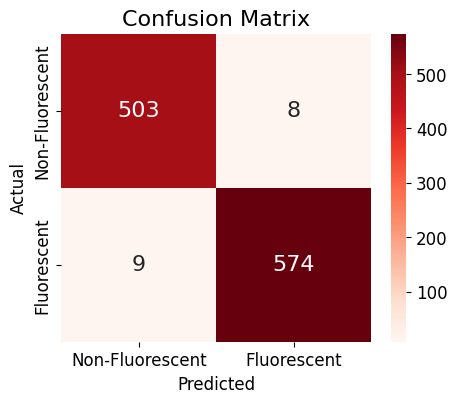

In [21]:
# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
conf_matrix = confusion_matrix(y_test, y_pred_labels_test)
heatmap = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=['Non-Fluorescent', 'Fluorescent'], yticklabels=['Non-Fluorescent', 'Fluorescent'], annot_kws={"size": 16})

plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.savefig("ConfusionMatrix.png", dpi=600, bbox_inches="tight")
plt.show()

**Interpretation**

In [22]:
# Integrated Gradints Interpretation Definition

def integrated_gradients(inputs, model, baseline=None, steps=50):
    if baseline is None:
        baseline = tf.zeros(shape=inputs.shape)

    # (1)  Define the interpolation path between the baseline and the input
    interpolated_inputs = [
        baseline[0] + (float(i) / steps) * (inputs[0] - baseline[0])
        for i in range(steps + 1)
    ]
    interpolated_inputs = tf.convert_to_tensor(interpolated_inputs, dtype=tf.float32)

    # (2) Gradient Calculation
    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        predictions = model(interpolated_inputs)
        target_predictions = tf.squeeze(predictions, axis=1)  # shape: (steps+1,)

    grads = tape.gradient(target_predictions, interpolated_inputs)

    # (3) Average Gradient Calculation
    avg_grads = tf.reduce_mean(grads, axis=0)

    # (4) Integrated Gradients Calculation
    integrated_grads = (inputs - baseline)[0] * avg_grads

    return integrated_grads.numpy()

**Local Interpretation - Fluorescent Molecule**

In [51]:
# Target sample molecule SMILES
sample_smiles = 'Cc1cccc(C2=C(c3cccc(C)c3)C3=Cc4ccccc4NB3OB3Nc4ccccc4C=C32)c1'      # Fluorescent

# Convert SMILES to ECFP (radius=4, nBits=2048)
mol = Chem.MolFromSmiles(sample_smiles)
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048)

# Extract active bit positions
on_bits = list(fp.GetOnBits())
on_bits_num = len(on_bits)

# Convert fingerprint to NumPy array
sample_input = np.array(fp).reshape(1, -1)

# print
print(f"SMILES: {sample_smiles}")
print(f"Bit   : {sample_input.tolist()}")
print(f"Number of active bits: {on_bits_num}")
print(f"Activated bit position (index): {list(fp.GetOnBits())}")

SMILES: Cc1cccc(C2=C(c3cccc(C)c3)C3=Cc4ccccc4NB3OB3Nc4ccccc4C=C32)c1
Bit   : [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

[11:55:12] DEPRECATION WARNING: please use MorganGenerator


In [52]:
# IG Calculation
ig_result = integrated_gradients(
    inputs=tf.convert_to_tensor(sample_input, dtype=tf.float32),
    model=model,
    steps=100  # If baseline is None, a zero vector is used automatically.
)

# Check Result
print("Integrated Gradients shape:", ig_result.shape)  # (2048,) expected
print("Importance Index:", np.argsort(-np.abs(ig_result))[:on_bits_num])

Integrated Gradients shape: (2048,)
Importance Index: [1160  692  656 1714 1307 1398 2023  114  736 1235  917 1113 1380 1913
  956  701 1405 1920  236 1039  960 1586 1846   26 1239 1013 1250 1437
 1639 1055 1057 1257 1029 1823  207 1510   19  875 1742  225 1936   84
 1348 1199 1114 1088 1470 1594  763   29 1873 1982 1165 1722 1750 1024
  357  506 1550 1448 1721 1102]


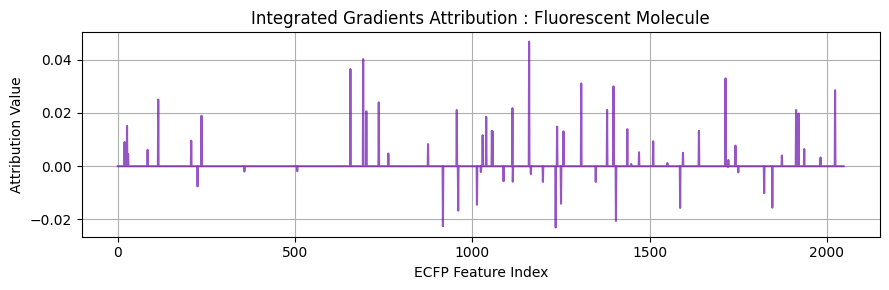

In [53]:
# Attribution Distribution Visualization
plt.figure(figsize=(9, 3))
plt.plot(np.arange(len(ig_result)), ig_result, color='#6A0DAD', alpha=0.7)
plt.title('Integrated Gradients Attribution : Fluorescent Molecule')
plt.xlabel('ECFP Feature Index')
plt.ylabel('Attribution Value')
plt.grid(True)
plt.tight_layout()
# plt.savefig("IG_attribution_F.png", dpi=600, bbox_inches="tight")
plt.show()

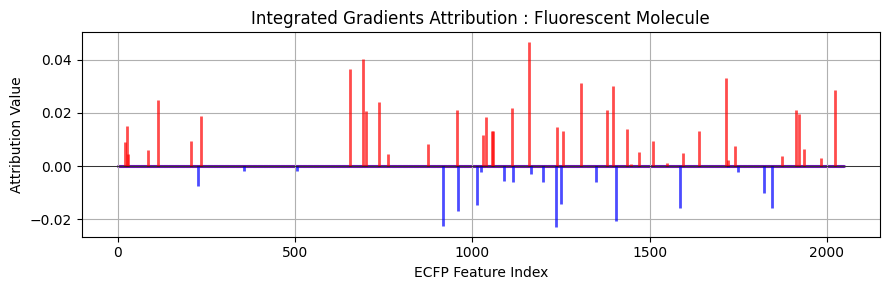

In [54]:
# Attribution Distribution Visualization

ig = np.array(ig_result).astype(float).reshape(-1)
x = np.arange(len(ig))

plt.figure(figsize=(9, 3))

pos_idx = ig > 0
neg_idx = ig < 0
zero_idx = ig == 0

plt.vlines(x[pos_idx], 0, ig[pos_idx], color='red', alpha=0.7, linewidth=2)
plt.vlines(x[neg_idx], 0, ig[neg_idx], color='blue', alpha=0.7, linewidth=2)
#plt.vlines(x[zero_idx], 0, ig[zero_idx], color='#6A0DAD', alpha=0.7, linewidth=2)
plt.scatter(x[zero_idx], np.zeros_like(x[zero_idx]), color='#6A0DAD', s=1.5, alpha=0.6)

plt.axhline(0, color='black', linewidth=0.5)
plt.title('Integrated Gradients Attribution : Fluorescent Molecule')
plt.xlabel('ECFP Feature Index')
plt.ylabel('Attribution Value')
plt.grid(True)
plt.tight_layout()

plt.savefig("IG_attribution_color_F.png", dpi=600, bbox_inches="tight")
plt.show()

In [55]:
# Top contributing features
top_k = on_bits_num
top_indices = np.argsort(-np.abs(ig_result))[:top_k]   # Select top_k candidates based on absolute value
top_indices = top_indices[np.argsort(-ig_result[top_indices])]  # Sort the selected top_k by the "value" (+ → -)
top_values = ig_result[top_indices]

top_features_df = pd.DataFrame({
    "Rank": np.arange(1, len(top_indices) + 1),
    "Feature Index": top_indices,
    "Attribution Value": top_values
})

# (Option) Add contribution direction for interpretation
top_features_df["Contribution"] = top_features_df["Attribution Value"].apply(
    lambda x: "Positive (+)" if x > 0 else "Negative (−)"
)

# CSV Save
top_features_df.to_csv("top_features_IG_sorted_by_value_F.csv", index=False)

# display result
display(top_features_df)


,Rank,Feature Index,Attribution Value,Contribution
0,1,1160,0.046786,Positive (+)
1,2,692,0.040218,Positive (+)
2,3,656,0.036485,Positive (+)
3,4,1714,0.032977,Positive (+)
4,5,1307,0.031074,Positive (+)
...,...,...,...,...
57,58,1586,-0.015648,Negative (−)
58,59,960,-0.016679,Negative (−)
59,60,1405,-0.020532,Negative (−)
60,61,917,-0.022512,Negative (−)


[11:55:33] DEPRECATION WARNING: please use MorganGenerator


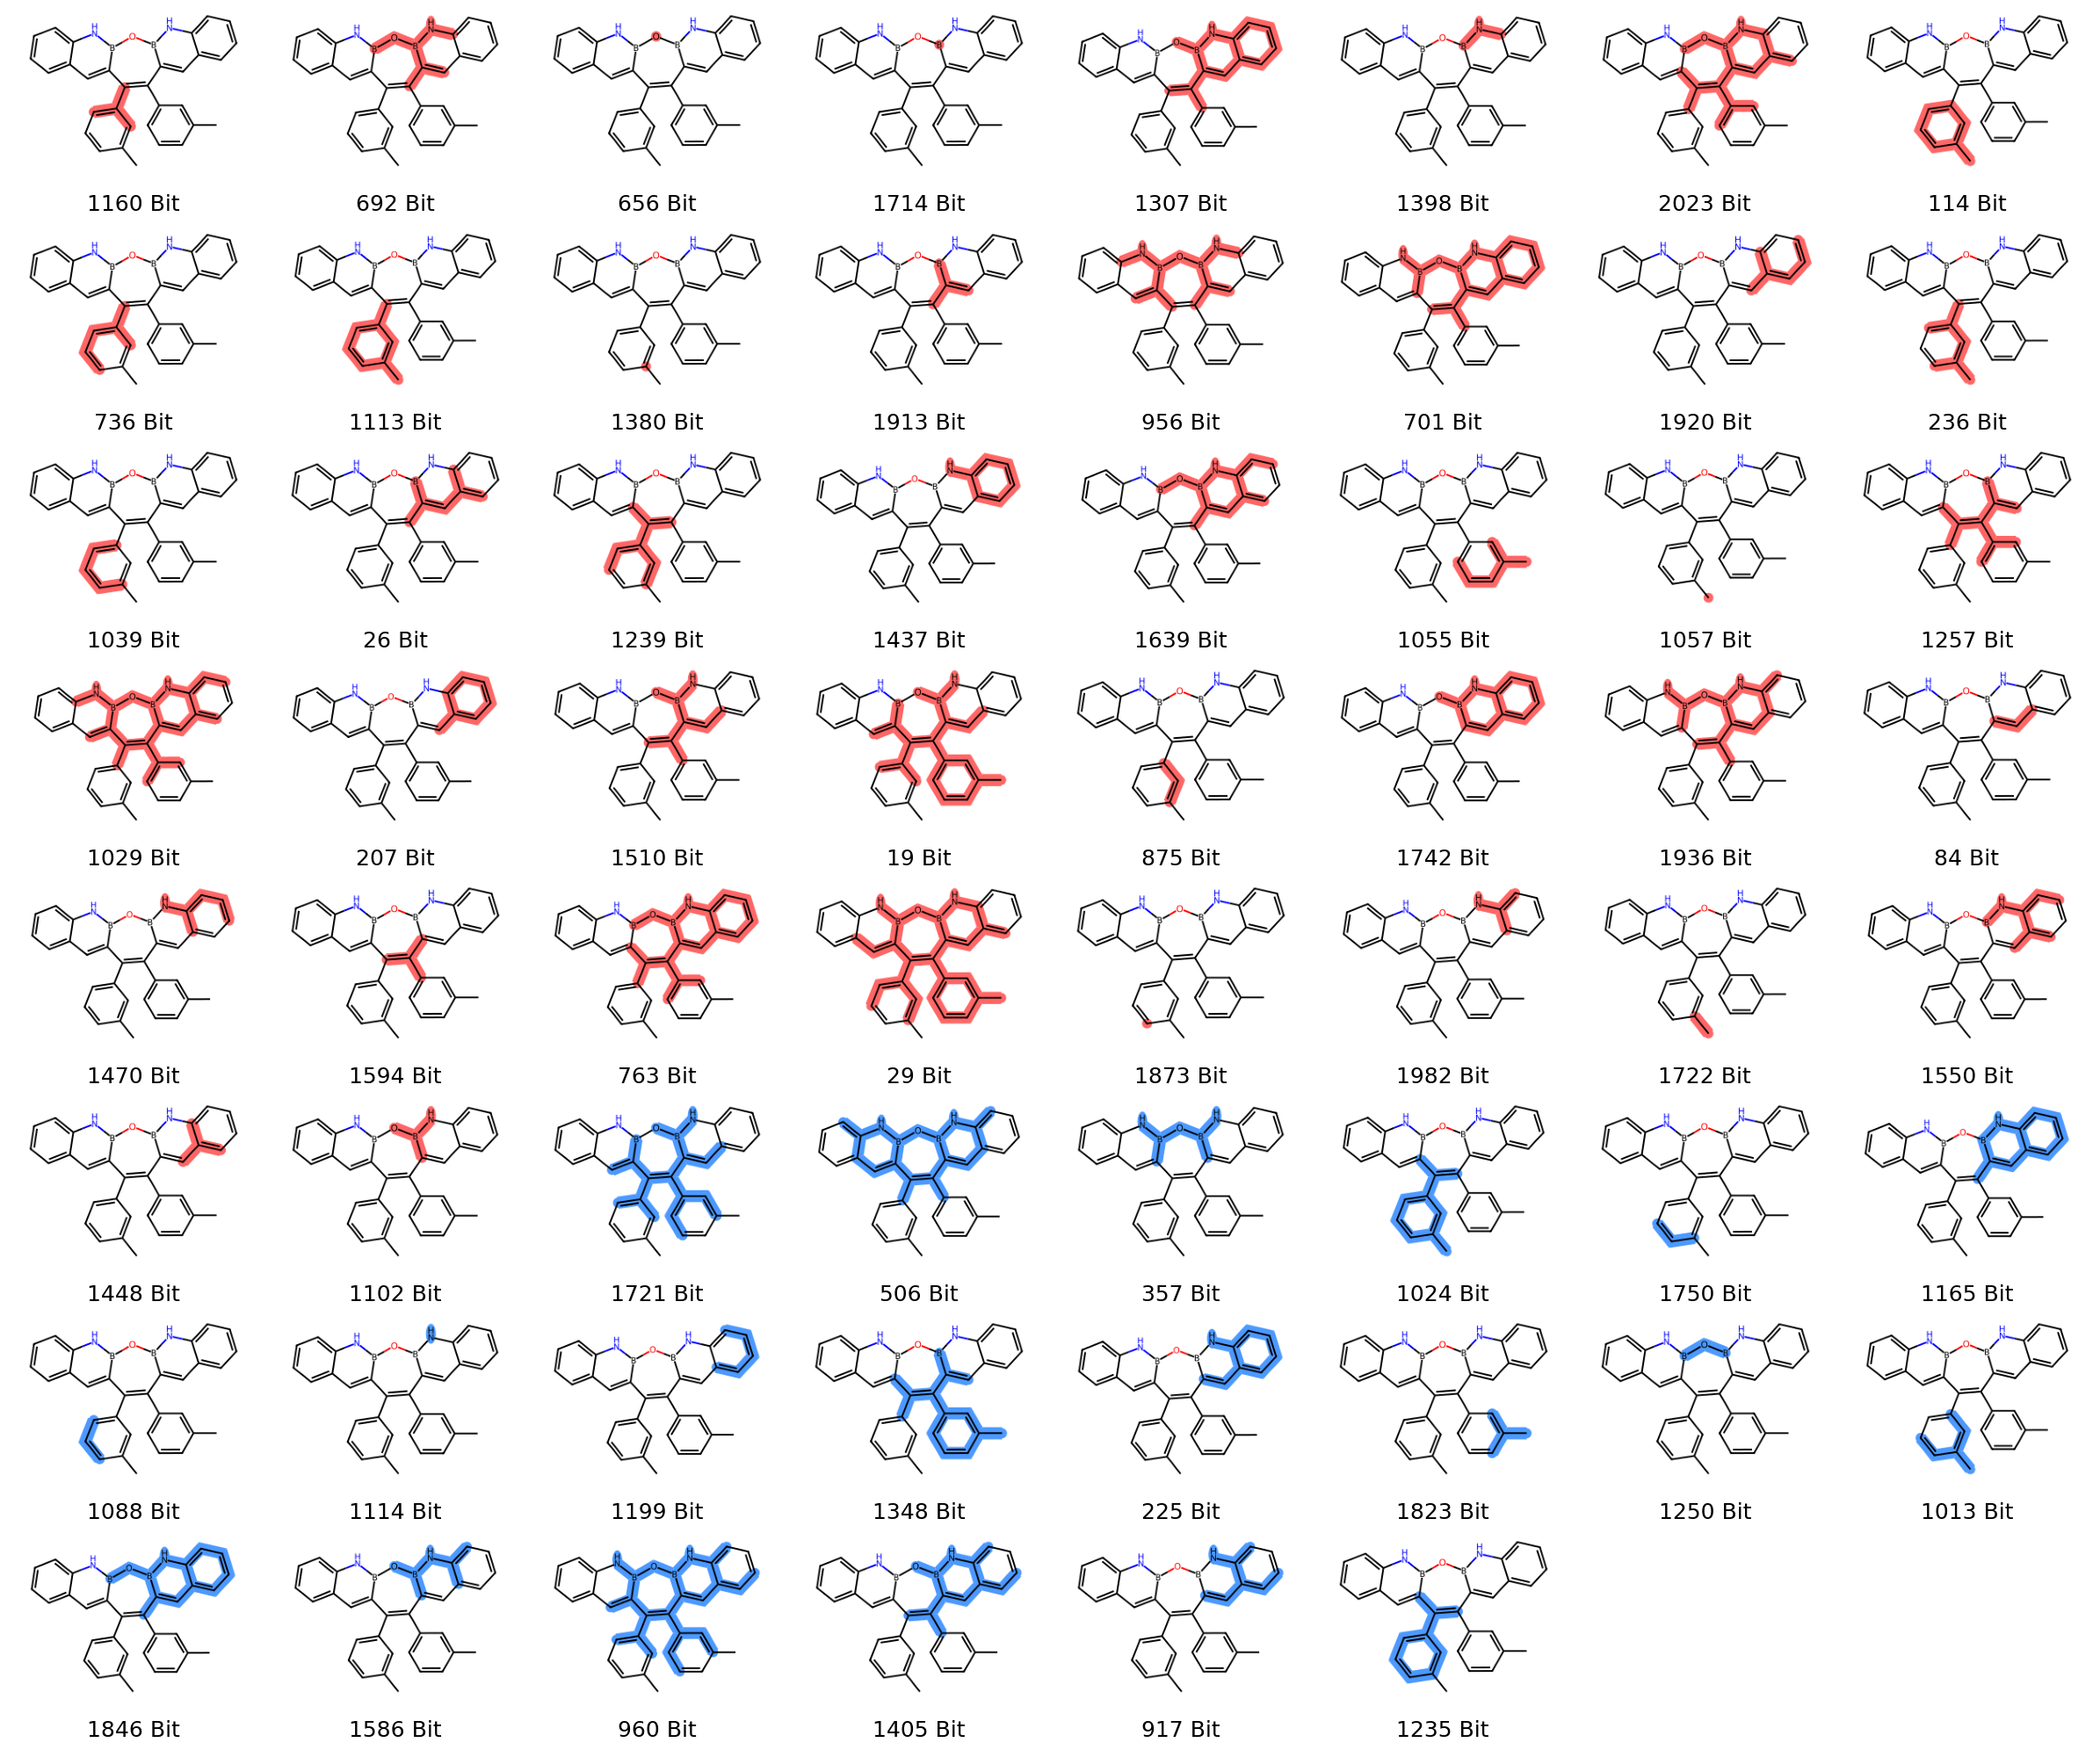

In [56]:
# Visualize top contributing features

# Create bitInfo
bitInfo = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048, bitInfo=bitInfo)

# Visualize each Top bit
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

images = []
titles = []

for i, bit in enumerate(top_indices[:top_k]):
    if bit in bitInfo:
        for atom_idx, radius in bitInfo[bit]:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)

            highlight_atoms = set()
            highlight_bonds = set()
            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                highlight_bonds.add(bidx)
                highlight_atoms.add(bond.GetBeginAtomIdx())
                highlight_atoms.add(bond.GetEndAtomIdx())
            highlight_atoms.add(atom_idx)

            mol_copy = Chem.Mol(mol)
            rdMolDraw2D.PrepareMolForDrawing(mol_copy)

            drawer = rdMolDraw2D.MolDraw2DCairo(300, 200)

            # Color specification by IG code
            if ig_result[bit] < 0:
                highlight_color = (0.3, 0.6, 1.0)   # Blue (Negative contribution)
            else:
                highlight_color = (1.0, 0.4, 0.4)   # Red (Positive contribution)

            atom_colors = {idx: highlight_color for idx in highlight_atoms}
            bond_colors = {idx: highlight_color for idx in highlight_bonds}

            drawer.drawOptions().highlightBondWidthMultiplier = 20
            drawer.DrawMolecule(
                mol_copy,
                highlightAtoms=list(highlight_atoms),
                highlightBonds=list(highlight_bonds),
                highlightAtomColors=atom_colors,
                highlightBondColors=bond_colors,
            )
            drawer.FinishDrawing()
            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png))

            images.append(img)
            titles.append(f"{bit} Bit")
            break

# Visualization
fig, axes = plt.subplots(8, 8, figsize=(24, 20))  # Fluorescent (62/64)

for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        ax.imshow(images[idx])
        ax.axis('off')
        ax.text(
            0.5, -0.12, titles[idx], transform=ax.transAxes,
            ha='center', va='top', fontsize=18
        )
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig("IG_substructure_F.png", dpi=600, bbox_inches="tight")
plt.show()

**Local Interpretation - Non-Fluorescent Molecule**

In [63]:
# Target sample molecule SMILES
sample_smiles = 'CC(=O)OCCN(CCOC(C)=O)c1ccc(/N=N/c2c(Cl)cc([N+](=O)[O-])cc2Cl)cc1'  # Non-Fluorescent

# Convert SMILES to ECFP (radius=4, nBits=2048)
mol = Chem.MolFromSmiles(sample_smiles)
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048)

# Extract active bit positions
on_bits = list(fp.GetOnBits())
on_bits_num = len(on_bits)

# Convert fingerprint to NumPy array
sample_input = np.array(fp).reshape(1, -1)

# print
print(f"SMILES: {sample_smiles}")
print(f"Bit   : {sample_input.tolist()}")
print(f"Number of active bits: {on_bits_num}")
print(f"Activated bit position (index): {list(fp.GetOnBits())}")

SMILES: CC(=O)OCCN(CCOC(C)=O)c1ccc(/N=N/c2c(Cl)cc([N+](=O)[O-])cc2Cl)cc1
Bit   : [[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

[12:11:31] DEPRECATION WARNING: please use MorganGenerator


In [65]:
# IG Calculation
ig_result = integrated_gradients(
    inputs=tf.convert_to_tensor(sample_input, dtype=tf.float32),
    model=model,
    steps=100  # If baseline is None, a zero vector is used automatically.
)

# Check Result
print("Integrated Gradients shape:", ig_result.shape)  # (2048,) expected
print("Importance Index:", np.argsort(-np.abs(ig_result))[:on_bits_num])

Integrated Gradients shape: (2048,)
Importance Index: [ 931 1680  935 1583  725 1854  202   13 1665  650 1405 1388  695  618
  390 1687  147  148  853 1017 1809 1683   82 1917 1195 1274  960 1622
  710  602  807 1750 1281  270 1873  561  435 1077 1425 1668 1241 1035
  715 1775 1517  366 1715    5 1963  753 1812 1096  252 1380  830  423
  838  370  846   80  875 2001 1057  377 1786 1477  257 1951 1164  881
  312  674 1768]


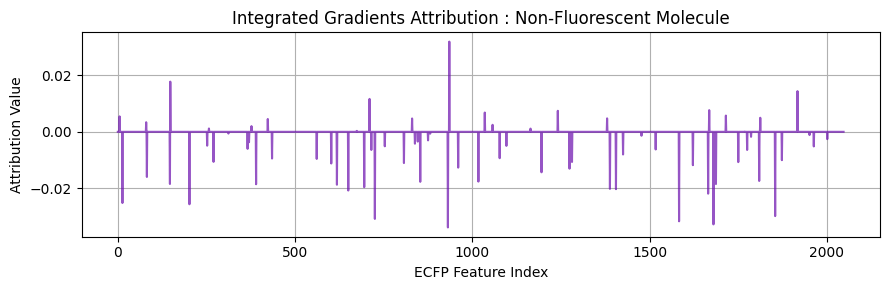

In [66]:
# Attribution Distribution Visualization
plt.figure(figsize=(9, 3))
plt.plot(np.arange(len(ig_result)), ig_result, color='#6A0DAD', alpha=0.7)
plt.title('Integrated Gradients Attribution : Non-Fluorescent Molecule')
plt.xlabel('ECFP Feature Index')
plt.ylabel('Attribution Value')
plt.grid(True)
plt.tight_layout()
# plt.savefig("IG_attribution_N.png", dpi=600, bbox_inches="tight")
plt.show()

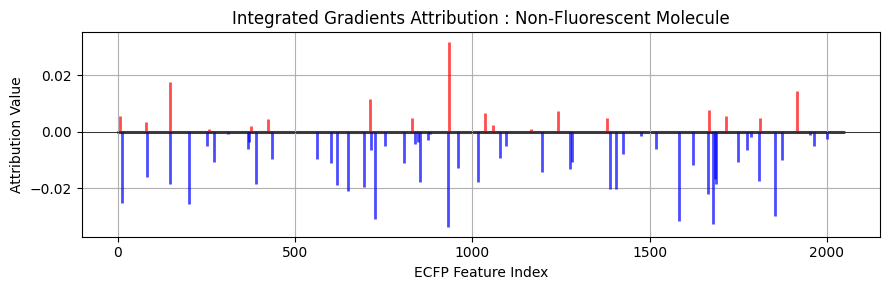

In [67]:
# Attribution Distribution Visualization

ig = np.array(ig_result).astype(float).reshape(-1)
x = np.arange(len(ig))

plt.figure(figsize=(9, 3))

pos_idx = ig > 0
neg_idx = ig < 0
zero_idx = ig == 0

plt.vlines(x[pos_idx], 0, ig[pos_idx], color='red', alpha=0.7, linewidth=2)
plt.vlines(x[neg_idx], 0, ig[neg_idx], color='blue', alpha=0.7, linewidth=2)
#plt.vlines(x[zero_idx], 0, ig[zero_idx], color='#6A0DAD', alpha=0.7, linewidth=2)
plt.scatter(x[zero_idx], np.zeros_like(x[zero_idx]), color='#6A0DAD', s=1.5, alpha=0.6)

plt.axhline(0, color='black', linewidth=0.5)
plt.title('Integrated Gradients Attribution : Non-Fluorescent Molecule')
plt.xlabel('ECFP Feature Index')
plt.ylabel('Attribution Value')
plt.grid(True)
plt.tight_layout()

plt.savefig("IG_attribution_color_N.png", dpi=600, bbox_inches="tight")
plt.show()

In [68]:
# Top contributing features
top_k = on_bits_num
top_indices = np.argsort(-np.abs(ig_result))[:top_k]   # Select top_k candidates based on absolute value
top_indices = top_indices[np.argsort(-ig_result[top_indices])]  # Sort the selected top_k by the "value" (+ → -)
top_values = ig_result[top_indices]

top_features_df = pd.DataFrame({
    "Rank": np.arange(1, len(top_indices) + 1),
    "Feature Index": top_indices,
    "Attribution Value": top_values
})

# (Option) Add contribution direction for interpretation
top_features_df["Contribution"] = top_features_df["Attribution Value"].apply(
    lambda x: "Positive (+)" if x > 0 else "Negative (−)"
)

# CSV Save
top_features_df.to_csv("top_features_IG_sorted_by_value_N.csv", index=False)

# display result
display(top_features_df)


,Rank,Feature Index,Attribution Value,Contribution
0,1,935,0.031829,Positive (+)
1,2,148,0.017703,Positive (+)
2,3,1917,0.014357,Positive (+)
3,4,710,0.011612,Positive (+)
4,5,1668,0.007654,Positive (+)
...,...,...,...,...
68,69,1854,-0.029733,Negative (−)
69,70,725,-0.030731,Negative (−)
70,71,1583,-0.031572,Negative (−)
71,72,1680,-0.032663,Negative (−)


[12:11:56] DEPRECATION WARNING: please use MorganGenerator


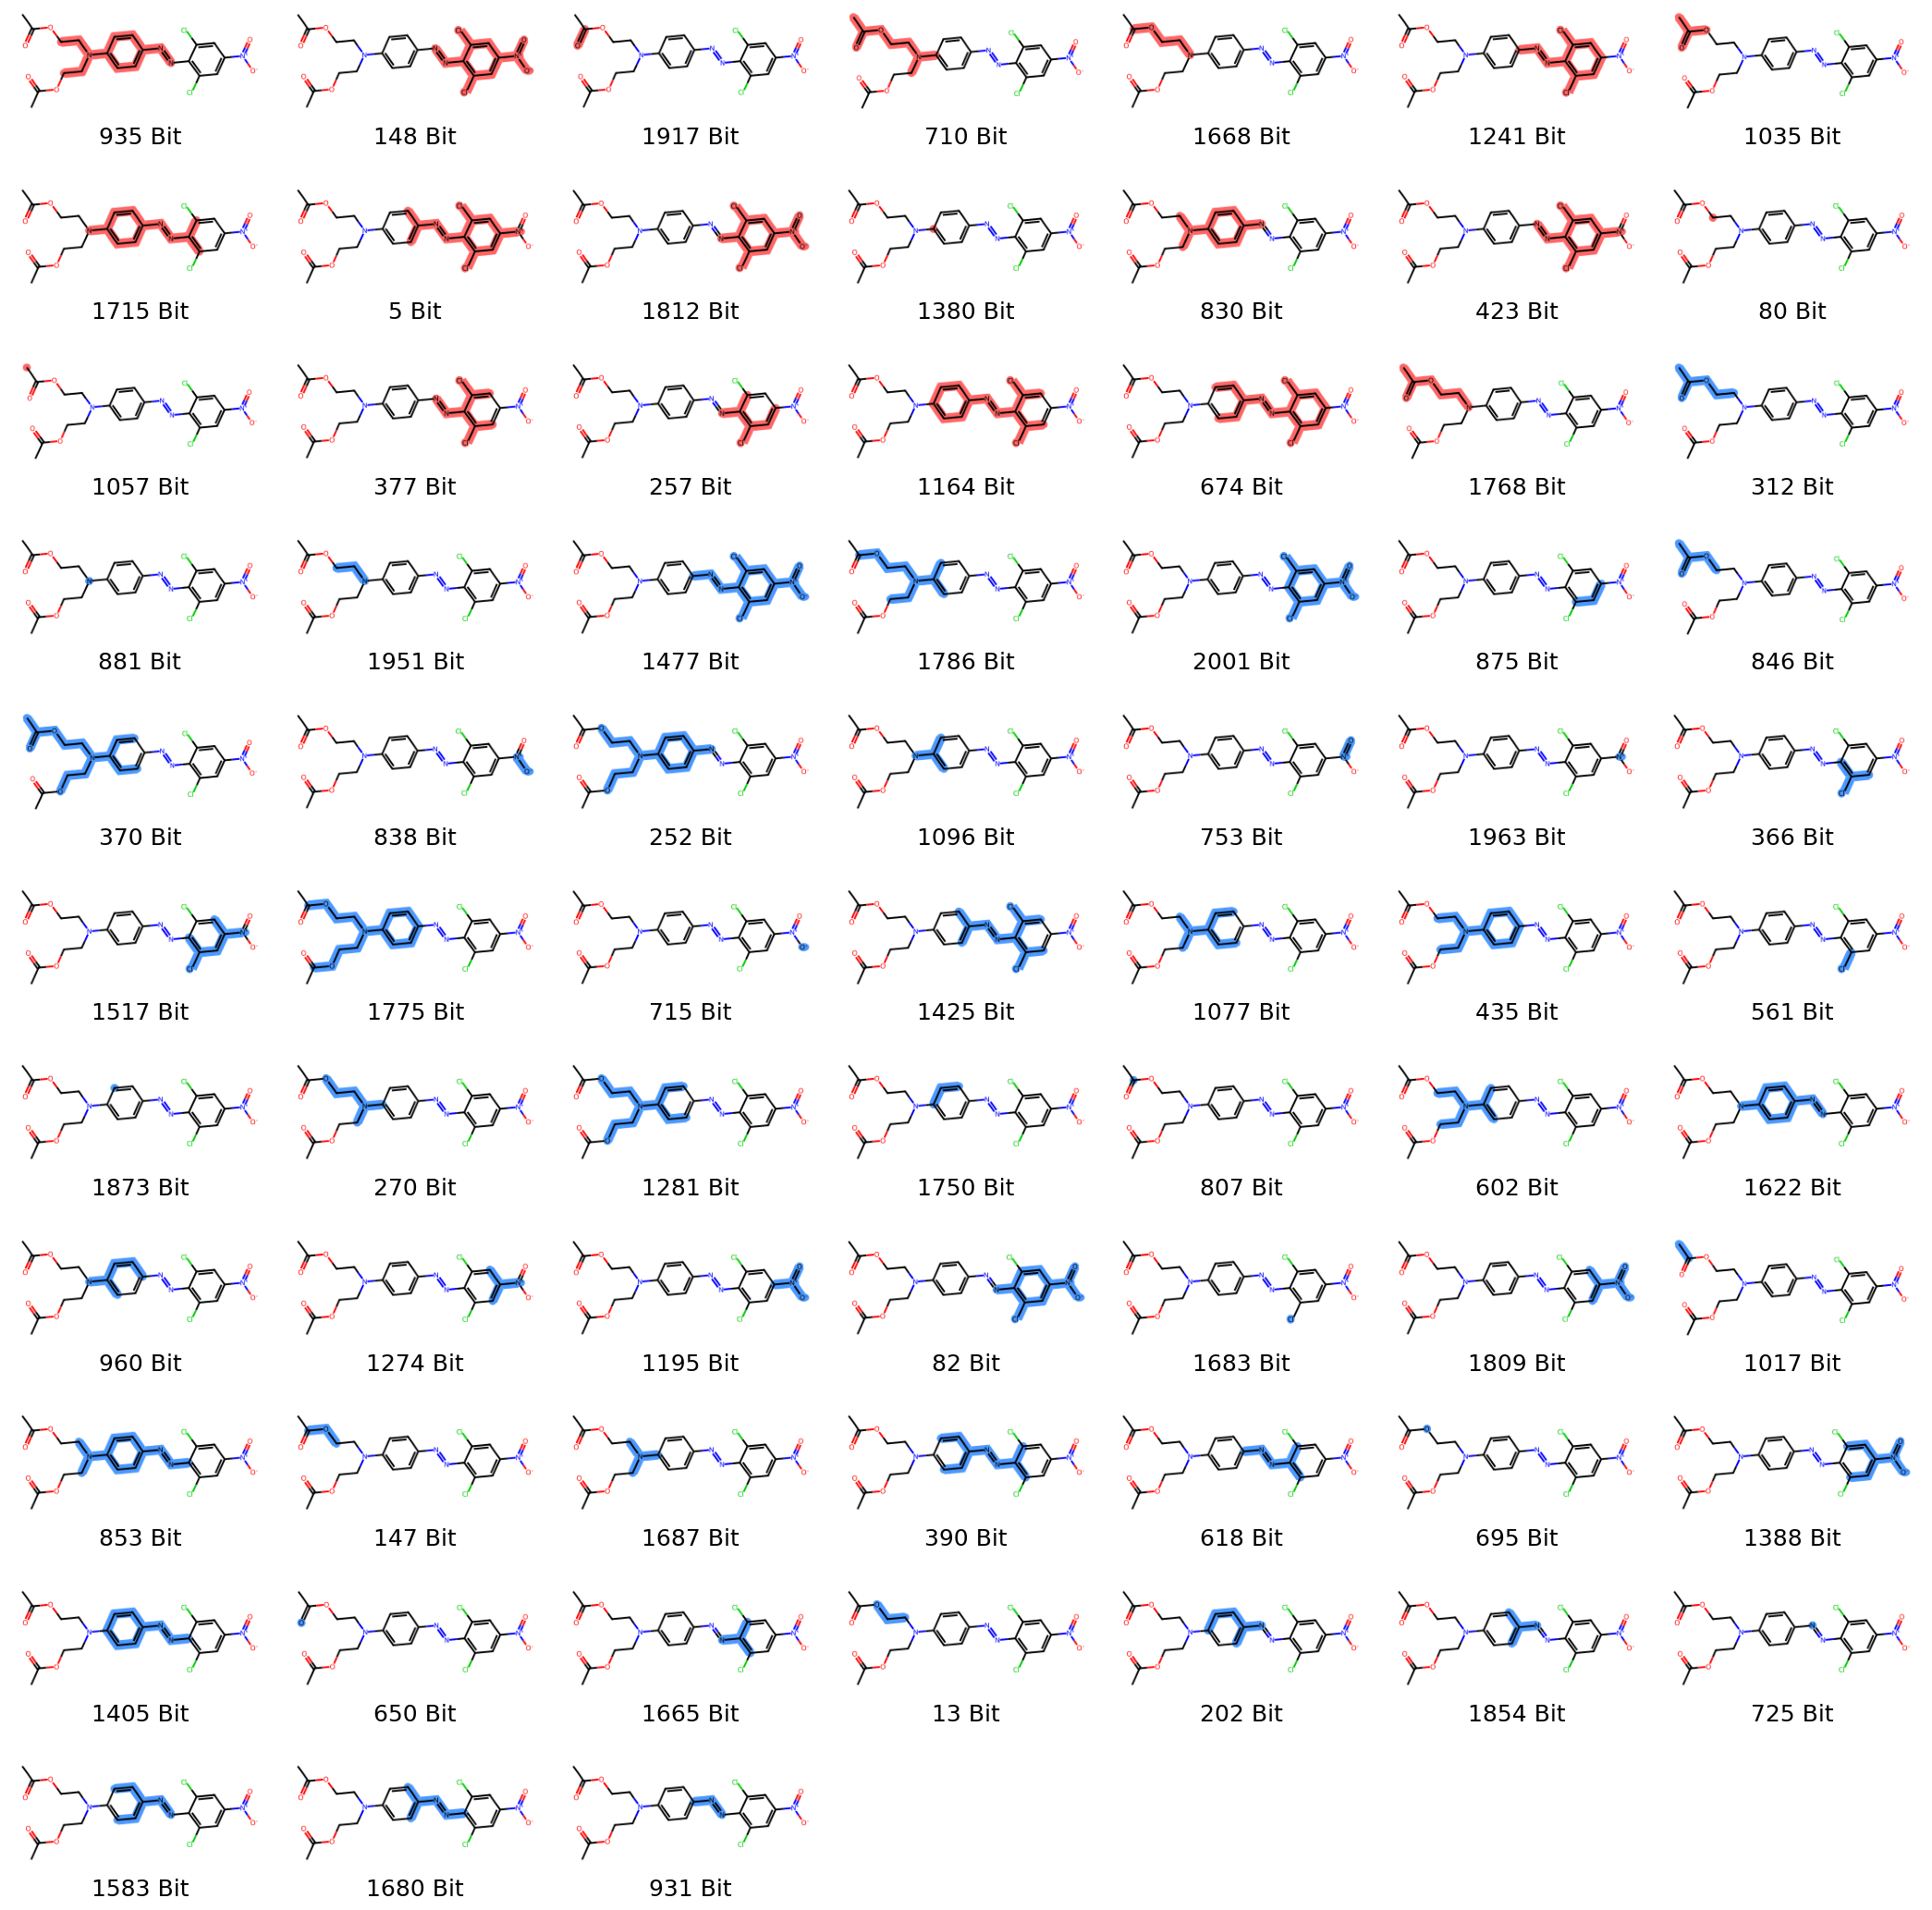

In [69]:
# Visualize top contributing features

# Create bitInfo
bitInfo = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048, bitInfo=bitInfo)

# Visualize each Top bit
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

images = []
titles = []

for i, bit in enumerate(top_indices[:top_k]):
    if bit in bitInfo:
        for atom_idx, radius in bitInfo[bit]:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)

            highlight_atoms = set()
            highlight_bonds = set()
            for bidx in env:
                bond = mol.GetBondWithIdx(bidx)
                highlight_bonds.add(bidx)
                highlight_atoms.add(bond.GetBeginAtomIdx())
                highlight_atoms.add(bond.GetEndAtomIdx())
            highlight_atoms.add(atom_idx)

            mol_copy = Chem.Mol(mol)
            rdMolDraw2D.PrepareMolForDrawing(mol_copy)

            drawer = rdMolDraw2D.MolDraw2DCairo(300, 120)

            # Color specification by IG code
            if ig_result[bit] < 0:
                highlight_color = (0.3, 0.6, 1.0)   # Blue (Negative contribution)
            else:
                highlight_color = (1.0, 0.4, 0.4)   # Red (Positive contribution)

            atom_colors = {idx: highlight_color for idx in highlight_atoms}
            bond_colors = {idx: highlight_color for idx in highlight_bonds}

            drawer.drawOptions().highlightBondWidthMultiplier = 20
            drawer.DrawMolecule(
                mol_copy,
                highlightAtoms=list(highlight_atoms),
                highlightBonds=list(highlight_bonds),
                highlightAtomColors=atom_colors,
                highlightBondColors=bond_colors,
            )
            drawer.FinishDrawing()
            png = drawer.GetDrawingText()
            img = Image.open(io.BytesIO(png))

            images.append(img)
            titles.append(f"{bit} Bit")
            break

# Visualization
fig, axes = plt.subplots(11, 7, figsize=(21, 21))  # Non-Fluorescent (73/77)

for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        ax.imshow(images[idx])
        ax.axis('off')
        ax.text(
            0.5, -0.12, titles[idx], transform=ax.transAxes,
            ha='center', va='top', fontsize=18
        )
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig("IG_substructure_N.png", dpi=600, bbox_inches="tight")
plt.show()

**Global Interpretation**

In [72]:
# ============================================================
# mol_table
# ------------------------------------------------------------
# Molecule-level metadata table
# Includes:
# - Molecule ID
# - SMILES
# - True class label (y_true / Class)
# - Number of active ECFP bits
# - Predicted probability
# - Predicted class label
# - Prediction correctness
# ============================================================

mol_table = df.copy()
mol_table.insert(0, 'mol_id', np.arange(len(mol_table), dtype=int))  # Unique ID
mol_table['y_true'] = mol_table['Class'].astype(int)
mol_table = mol_table.drop(columns=['Class'])

# X_fp : All molecular ECFP conversion results
smiles_list = mol_table['SMILES'].tolist()
X_fp = np.array([smiles_to_fingerprint(smi, radius=4, n_bits=2048) for smi in smiles_list], dtype=np.int8)

# Number of active bits per molecule
mol_table['onbit_count'] = X_fp.sum(axis=1).astype(int)

# Predicted Label
mol_table['y_pred_label'] = pd.NA
mol_table.loc[idx_train, 'y_pred_label'] = np.array(y_pred_labels_train).reshape(-1).astype(int)
mol_table.loc[idx_test,  'y_pred_label'] = np.array(y_pred_labels_test).reshape(-1).astype(int)

# Correct or not
mol_table['correct'] = pd.NA
mask_known = mol_table['y_pred_label'].notna()
mol_table.loc[mask_known, 'correct'] = (mol_table.loc[mask_known, 'y_true'].astype(int)
                                        == mol_table.loc[mask_known, 'y_pred_label'].astype(int))

# (Option) Sort
cols_order = ['mol_id', 'SMILES', 'y_true', 'y_pred_label', 'correct', 'onbit_count']     # split
mol_table = mol_table[cols_order]

print("mol_table shape:", mol_table.shape)
display(mol_table)

mol_table shape: (5466, 6)


,mol_id,SMILES,y_true,y_pred_label,correct,onbit_count
0,0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2,0,0,True,105
1,1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2,0,0,True,105
2,2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2,0,0,True,110
3,3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1,0,0,True,87
4,4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2,0,0,True,112
...,...,...,...,...,...,...
5461,5461,CN(C)c1ccc(-c2ccc3c(=O)c(O)coc3c2)cc1,1,1,True,58
5462,5462,COc1coc2cc(-c3ccc(N(C)C)cc3)ccc2c1=O,1,1,True,61
5463,5463,COC(=O)CN1C(=O)c2cc3ccc(N(C)C)cc3cc2C1=O,1,1,True,62
5464,5464,CCN(CC)c1ccc2c(c1)C(C)(C)c1cc(C=O)ccc1-2,1,1,True,58


In [73]:
mol_table.to_csv("mol_table.csv", index=False)

In [74]:
# ============================================================
# ig_matrix_raw
# ------------------------------------------------------------
# Raw IG attribution matrix
# Includes:
# - IG attribution values for all molecules
# - Rows: molecules
# - Columns: 2,048 ECFP bits
# - Values: raw IG attribution scores
# - Matrix shape: (number of molecules, 2048)
# ============================================================

def compute_ig_matrix(X_fp, model, steps=50, baseline_mode="zeros", verbose=1):
    """
    X_fp: (n_mol, 2048) numpy array (0/1)
    return: ig_matrix_raw (n_mol, 2048) float32
    """
    X_fp = X_fp.astype(np.float32)
    n, d = X_fp.shape
    ig_matrix = np.zeros((n, d), dtype=np.float32)

    # Prepare the baseline (use the same baseline for each sample)
    if baseline_mode == "zeros":
        baseline = np.zeros((1, d), dtype=np.float32)
    else:
        raise ValueError("baseline_mode currently supports only 'zeros'")

    for i in range(n):
        x = X_fp[i:i+1]  # shape (1, d)
        ig = integrated_gradients(x, model, baseline=baseline, steps=steps)  # shape (d,)
        ig_matrix[i] = ig.astype(np.float32)

        if verbose and (i % 200 == 0):
            print(f"IG computed: {i}/{n}")

    if verbose:
        print(f"Done. ig_matrix shape: {ig_matrix.shape}")
    return ig_matrix

# run
ig_matrix_raw = compute_ig_matrix(X_fp, model, steps=50, baseline_mode="zeros", verbose=1)
display(ig_matrix_raw)

IG computed: 0/5466
IG computed: 200/5466
IG computed: 400/5466
IG computed: 600/5466
IG computed: 800/5466
IG computed: 1000/5466
IG computed: 1200/5466
IG computed: 1400/5466
IG computed: 1600/5466
IG computed: 1800/5466
IG computed: 2000/5466
IG computed: 2200/5466
IG computed: 2400/5466
IG computed: 2600/5466
IG computed: 2800/5466
IG computed: 3000/5466
IG computed: 3200/5466
IG computed: 3400/5466
IG computed: 3600/5466
IG computed: 3800/5466
IG computed: 4000/5466
IG computed: 4200/5466
IG computed: 4400/5466
IG computed: 4600/5466
IG computed: 4800/5466
IG computed: 5000/5466
IG computed: 5200/5466
IG computed: 5400/5466
Done. ig_matrix shape: (5466, 2048)


array([[ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.        ],
       [ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.        ],
       [ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.        ],
       ...,
       [ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.        ],
       [ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.01084226],
       [ 0.        , -0.        ,  0.        , ...,  0.        ,
        -0.        , -0.02223426]], dtype=float32)

In [75]:
np.save("ig_matrix_raw.npy", ig_matrix_raw)

In [76]:
# ig_long_table : 분자에서 1인 비트 정보만 롱포멧으로 저장한 데이터, ECFP는 sparse 하므
# ============================================================
# ig_long_table
# ------------------------------------------------------------
# Long-format IG attribution table (ig_long_table)
# Includes:
# - Stores only active ECFP bits (bit value = 1) since ECFP is rare
# - One row per molecule-bit pair
# - Includes molecule ID and true class label
# - Includes ECFP bit index
# - Includes raw and absolute IG attribution values
# - Includes attribution direction (positive / negative)
# - Designed for molecule- and bit-level attribution analysis
# ============================================================

def build_ig_long_table(mol_table, X_fp, ig_matrix_raw, include_split=True):

    rows = []
    mol_ids = mol_table['mol_id'].values
    y_true = mol_table['y_true'].values

    # has_split = include_split and ('split' in mol_table.columns)
    # split_vals = mol_table['split'].values if has_split else None

    for i in range(X_fp.shape[0]):
        on_bits = np.where(X_fp[i] == 1)[0]
        ig_vals = ig_matrix_raw[i, on_bits]

        if len(on_bits) == 0:
            continue

        df_i = pd.DataFrame({
            'mol_id': mol_ids[i],
            'y_true': int(y_true[i]),
            'bit': on_bits.astype(int),
            'ig_raw': ig_vals.astype(float),
        })
        df_i['ig_abs'] = np.abs(df_i['ig_raw'])
        df_i['ig_direction'] = np.sign(df_i['ig_raw']).astype(int)   # -1, 0, 1

        # if has_split:
        #     df_i['split'] = split_vals[i]

        rows.append(df_i)

    ig_long = pd.concat(rows, ignore_index=True)
    return ig_long

ig_long_table = build_ig_long_table(mol_table, X_fp, ig_matrix_raw, include_split=True)

print("ig_long_table shape:", ig_long_table.shape)
display(ig_long_table)

ig_long_table shape: (467571, 6)


,mol_id,y_true,bit,ig_raw,ig_abs,ig_direction
0,0,0,84,-0.001537,0.001537,-1
1,0,0,111,0.000539,0.000539,1
2,0,0,150,0.007166,0.007166,1
3,0,0,186,-0.009612,0.009612,-1
4,0,0,191,-0.017341,0.017341,-1
...,...,...,...,...,...,...
467566,5465,1,1980,0.010441,0.010441,1
467567,5465,1,2013,-0.015903,0.015903,-1
467568,5465,1,2014,0.012381,0.012381,1
467569,5465,1,2026,-0.010366,0.010366,-1


In [77]:
ig_long_table.to_csv("ig_long_table.csv", index=False)

In [79]:
# ============================================================
# ECFP bit mapping and substructure visualization
# Purpose:
# - Identify molecular environments corresponding to specific ECFP bits
# - Visualize the substructures associated with selected fingerprint bits
# - Retrieve molecules containing a selected bit for IG-based analysis
# ============================================================

from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image

# ------------------------------------------------------------
# A) Find occurrences of a selected ECFP bit in a molecule (based on Generator)
#    Returns the center atom index and radius for each occurrence
# ------------------------------------------------------------
def find_bit_occurrences_gen(smiles, target_bit, radius=4, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []

    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    _ = fpgen.GetFingerprint(mol, additionalOutput=ao)

    bit_info_map = ao.GetBitInfoMap()  # {bit: [(center_atom_idx, rad), ...]}
    occ = bit_info_map.get(int(target_bit), [])
    return [(int(a), int(r)) for (a, r) in occ]


# ------------------------------------------------------------
# B) Visualize the molecular environment corresponding to an ECFP bit
#    Highlights the atoms and bonds defined by the center atom and radius
# ------------------------------------------------------------
def draw_bit_env(smiles, center_atom_idx, rad, legend="", size=(420, 300)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    bond_ids = Chem.FindAtomEnvironmentOfRadiusN(mol, int(rad), int(center_atom_idx))
    highlight_bonds = list(bond_ids)

    highlight_atoms = {int(center_atom_idx)}
    for bidx in bond_ids:
        b = mol.GetBondWithIdx(int(bidx))
        highlight_atoms.add(b.GetBeginAtomIdx())
        highlight_atoms.add(b.GetEndAtomIdx())
    highlight_atoms = list(highlight_atoms)

    # Generate 2D coordinates
    Chem.rdDepictor.Compute2DCoords(mol)

    drawer = rdMolDraw2D.MolDraw2DCairo(int(size[0]), int(size[1]))
    drawer.DrawMolecule(
        mol,
        legend=legend,
        highlightAtoms=highlight_atoms,
        highlightBonds=highlight_bonds
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


# ------------------------------------------------------------
# C) Retrieve molecules containing a selected ECFP bit
#    Returns the corresponding IG records and molecule IDs
# ------------------------------------------------------------
def get_mols_for_bit(bit, mol_table, ig_long_table, sort_by="abs_ig"):
    bit = int(bit)
    sub = ig_long_table[ig_long_table["bit"] == bit].copy()

    mol_ids_all = sub["mol_id"].unique().tolist()

    # Summarize IG attribution at the molecule level for each bit
    # agg = sub.groupby("mol_id").agg(
    #     y_true=("y_true", "first"),
    #     raw_ig=("ig_raw", "mean"),
    #     direction_ig=("direction", "mean"),  # -1, 0, 1
    #     abs_ig=("abs_ig_raw", "max"),
    #     n_occ=("ig_raw", "size"),
    # ).reset_index()

    # Merge SMILES information
    sub = sub.merge(mol_table[["mol_id", "SMILES"]], on="mol_id", how="left")

    # Sort by IG attribution
    if sort_by == "ig_abs":
        sub = sub.sort_values("ig_abs", ascending=False)
    elif sort_by == "ig_raw":
        sub = sub.sort_values("ig_raw", ascending=False)

    return sub, mol_ids_all

In [81]:
# ============================================================
# Visualize a selected ECFP bit across all molecules
# - Retrieve molecules containing the selected bit
# - Sort molecules by IG attribution
# - Identify corresponding ECFP environments
# - Highlight and visualize the associated substructures
# ============================================================

def visualize_bit_across_all_mols(
    bit,
    mol_table,
    ig_long_table,
    radius=4,
    n_bits=2048,
    max_draw=30,                 # Maximum number of molecules to visualize (None = all)
    show_all_occurrences=False,  # Draw all occurrences if the bit appears multiple times in a molecule
    sort_by="abs_ig"             # Molecule sorting criterion
):
    # 1) Retrieve molecules containing the selected bit
    summary_df, mol_ids_all = get_mols_for_bit(bit, mol_table, ig_long_table, sort_by=sort_by)

    print(f"[Bit {bit}] Number of molecules containing this bit: {len(mol_ids_all)}")
    print("Molecule IDs (first 50):", mol_ids_all[:50])
    display(summary_df)

    # 2) Select molecules for visualization
    if max_draw is None:
        draw_df = summary_df
        print("Visualizing all molecules containing the selected bit.")
    else:
        draw_df = summary_df.head(int(max_draw))
        print(f"Visualizing the top {len(draw_df)} molecules.")

    # 3) Identify bit occurrences and visualize corresponding substructure highlights
    n_imgs = 0
    for _, row in draw_df.iterrows():
        mol_id = int(row["mol_id"])
        smi = row["SMILES"]
        if pd.isna(smi):
            continue

        occ_list = find_bit_occurrences_gen(smi, int(bit), radius=radius, n_bits=n_bits)
        if len(occ_list) == 0:
            continue

        # Draw either all occurrences or only the first occurrence
        occ_to_draw = occ_list if show_all_occurrences else [occ_list[0]]

        for (center_atom_idx, rad) in occ_to_draw:
            legend = f"mol_id={mol_id} | bit={bit} | center={center_atom_idx} | radius={rad} | y={row['y_true']}"
            png = draw_bit_env(smi, center_atom_idx, rad, legend=legend, size=(460, 320))
            if png is not None:
                display(Image(png))
                n_imgs += 1

    print(f"Total number of rendered images: {n_imgs}")
    return summary_df, mol_ids_all

[Bit 256] Number of molecules containing this bit: 99
Molecule IDs (first 50): [18, 22, 104, 225, 480, 482, 519, 1266, 1299, 1429, 1496, 1801, 1848, 1914, 2033, 2060, 2088, 2096, 2119, 2122, 2159, 2239, 2275, 2369, 2391, 2418, 2428, 2469, 2472, 2477, 2519, 2523, 2529, 2628, 2693, 2720, 2738, 2775, 2806, 2831, 2842, 2846, 2859, 2879, 2880, 2911, 2912, 2957, 2958, 2990]


,mol_id,y_true,bit,ig_raw,ig_abs,ig_direction,SMILES
85,4729,1,256,0.044659,0.044659,1,Cc1c(CC(=O)O)c(=O)oc2cc(N)c(S(=O)(=O)O)cc12
93,5107,1,256,0.036480,0.036480,1,COC(=O)C(C)(C)C1Oc2c(Br)cc(Br)cc2C(=O)/C1=C\O
62,3608,1,256,0.032016,0.032016,1,CCNc1cc2oc3c/c(=[NH+]/CC)c(C)cc-3c(-c3ccc(C(=O)ON4C(=O)C=CC4=O)cc3C(=O)[O-])c2cc1C
22,2275,0,256,0.028848,0.028848,1,O=C(O)c1c(Cl)c(Cl)c(Cl)c(Cl)c1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(Br)c(O)c(Br)cc12
23,2369,0,256,0.024438,0.024438,1,O=S(=O)([O][Na])Oc1c(-c2[nH]c3c(Cl)cc(Cl)cc3c2OS(=O)(=O)[O][Na])[nH]c2c(Cl)cc(Cl)cc12
...,...,...,...,...,...,...,...
37,2775,1,256,0.004307,0.004307,1,Cc1cc(/C=C/c2ccc(-c3cccc(Cl)c3)o2)n2c1C=C1C=CC=[N+]1[B-]2(F)F
41,2846,1,256,0.004210,0.004210,1,Cc1cc(/C=C/c2ccc(-c3ccc(Cl)cc3)o2)n2c1C=C1C=CC=[N+]1[B-]2(F)F
35,2720,1,256,0.004055,0.004055,1,COc1ccc(-c2ccc(/C=C/c3cc(C)c4n3[B-](F)(F)[N+]3=CC=CC3=C4)o2)cc1Cl
42,2859,1,256,0.003931,0.003931,1,Cc1cc(/C=C/c2ccc(-c3ccccc3Cl)o2)n2c1C=C1C=CC=[N+]1[B-]2(F)F


Visualizing the top 35 molecules.


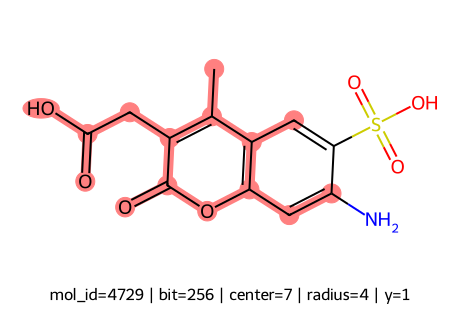

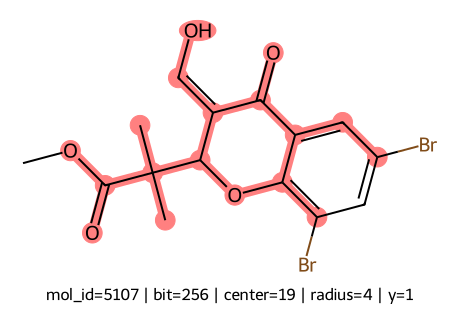

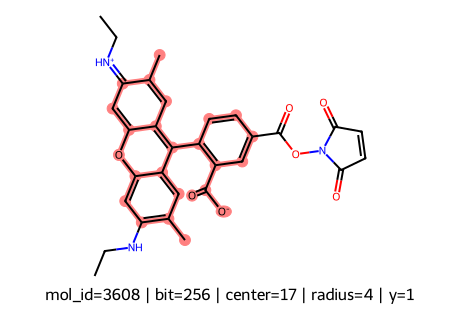

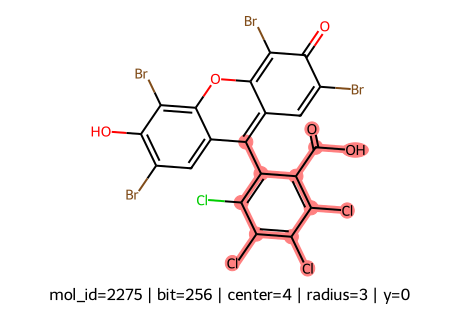

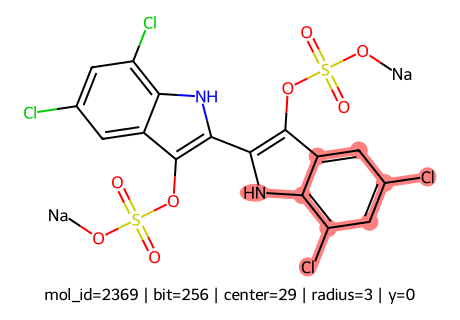

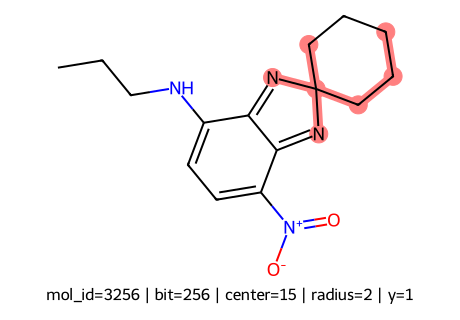

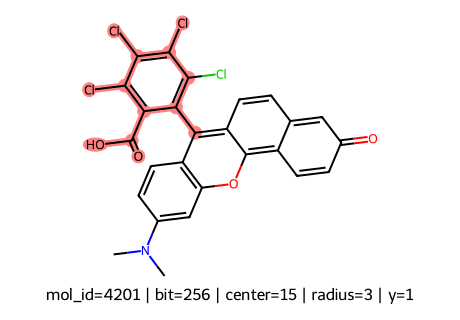

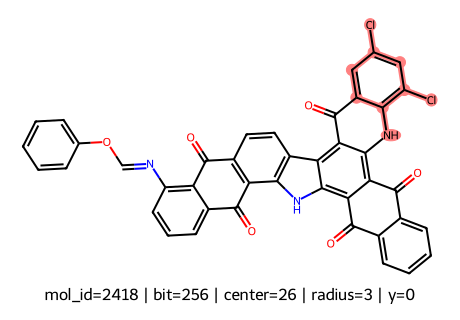

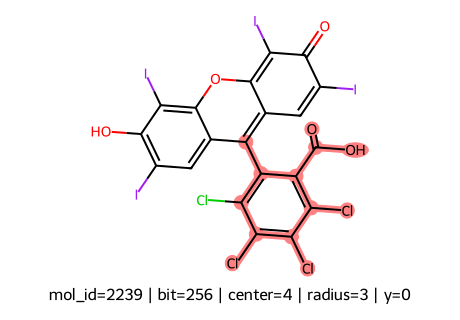

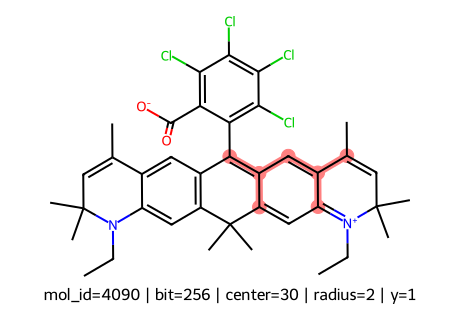

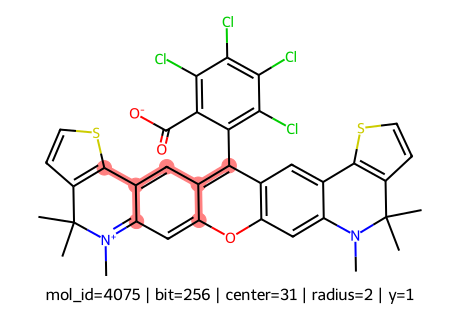

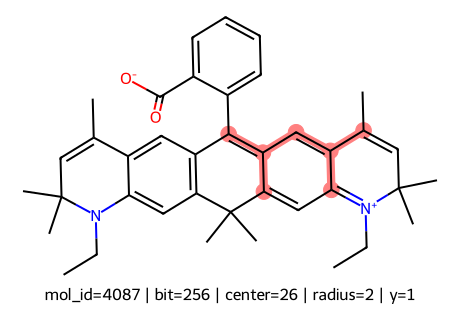

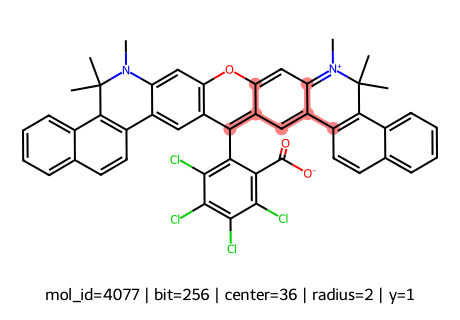

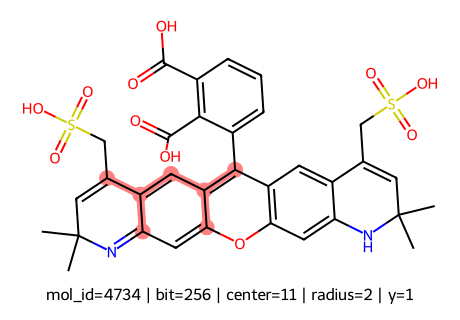

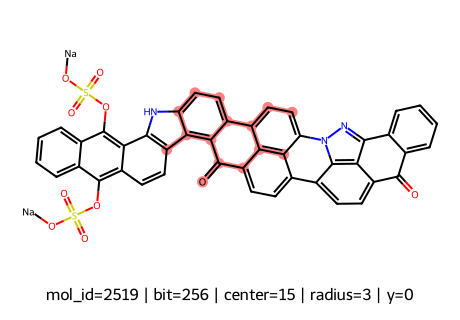

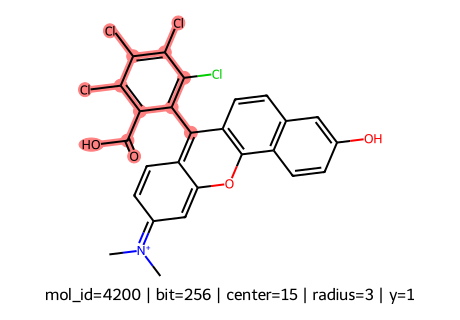

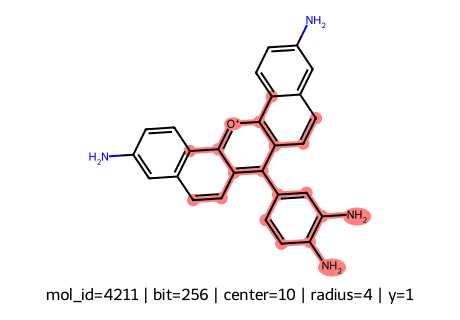

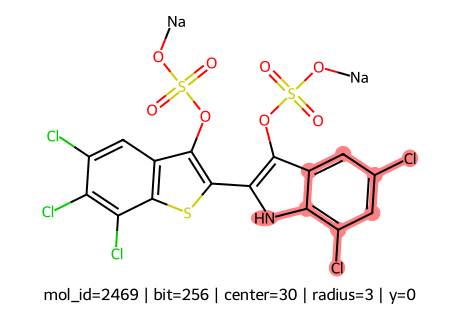

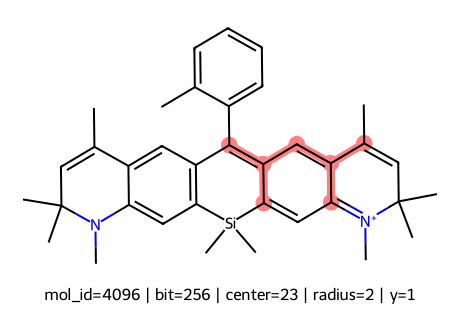

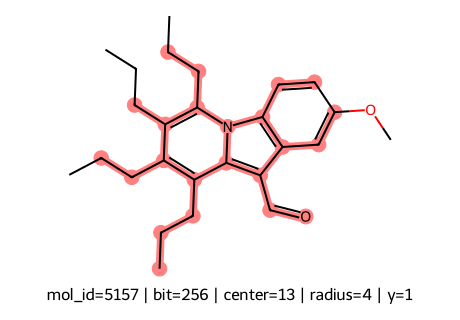

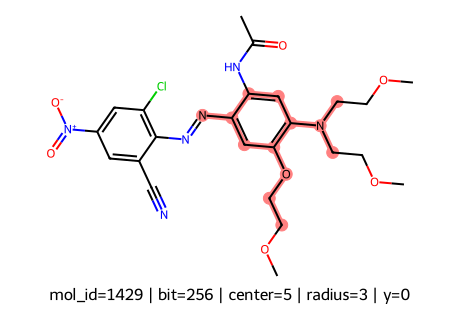

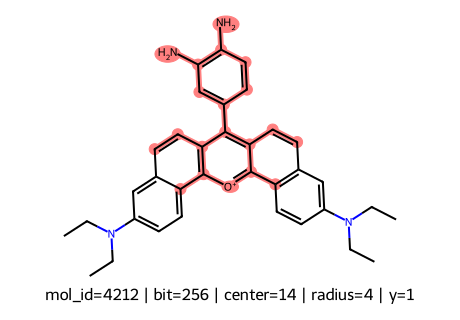

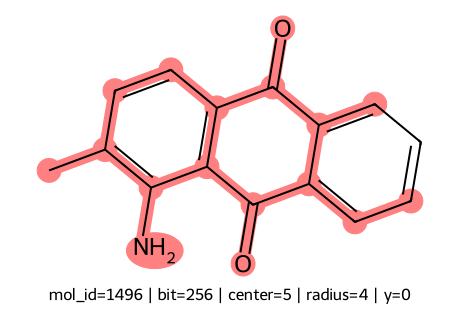

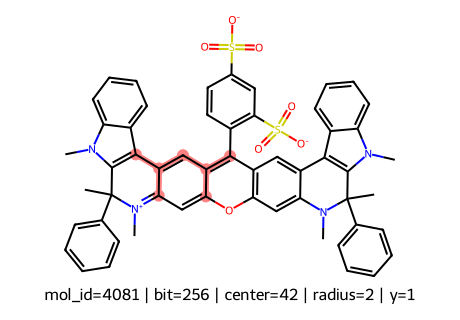

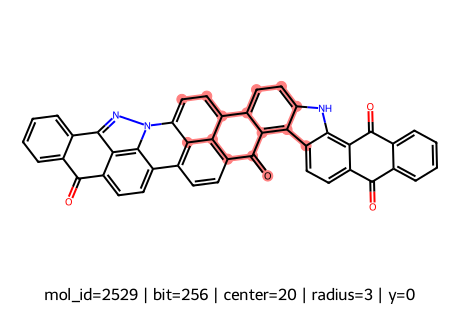

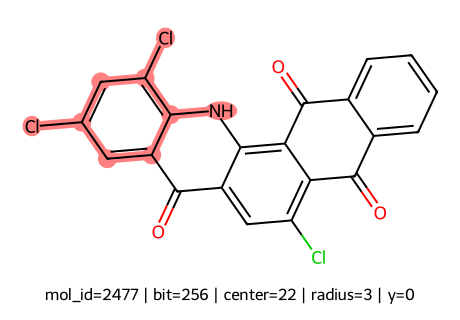

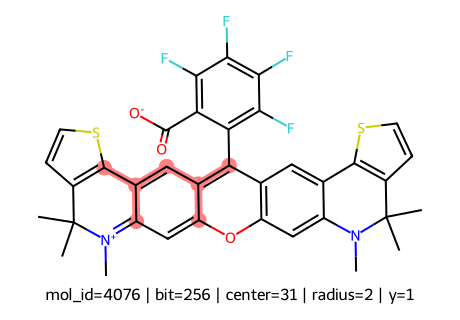

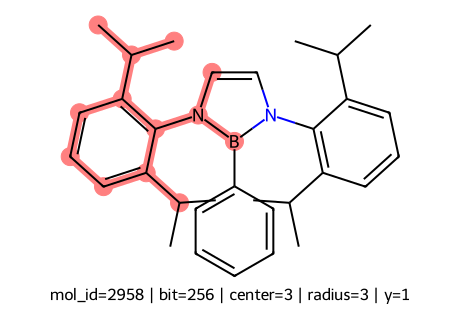

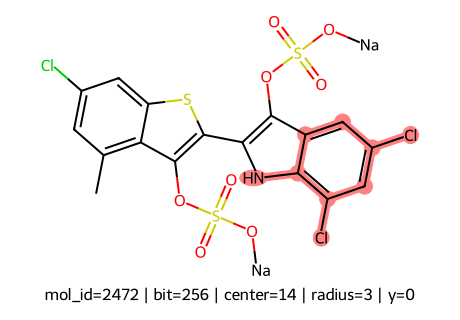

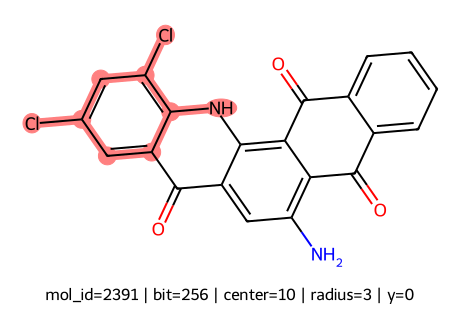

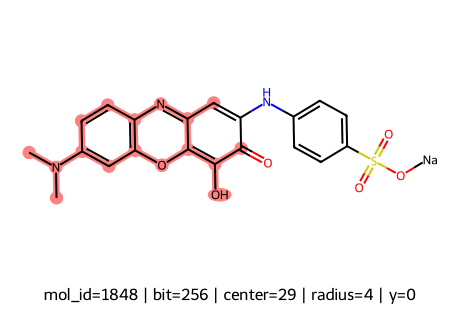

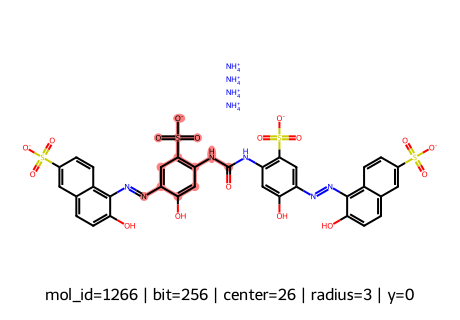

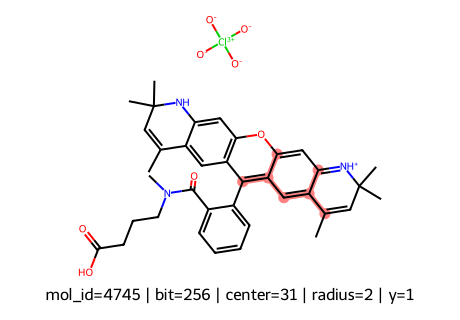

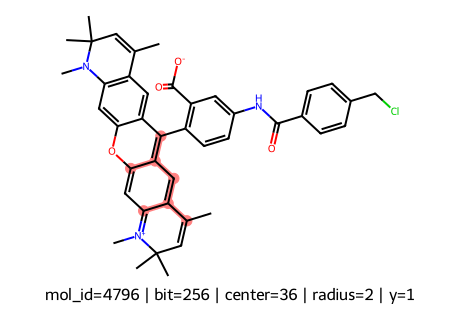

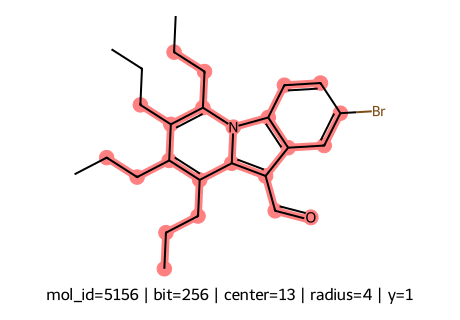

Total number of rendered images: 35


In [83]:
# ============================================================
# Visualize molecules containing a selected ECFP bit
# ============================================================
bit_id = 256
max_draw_num=35                 # First, 35 images only (all mol_ids are provided)

summary_df, mol_ids_all = visualize_bit_across_all_mols(
    bit=bit_id,
    mol_table=mol_table,
    ig_long_table=ig_long_table,
    radius=4,
    n_bits=2048,
    max_draw=max_draw_num,
    show_all_occurrences=False, # If there are multiple positions in one molecule, take only the first one
    sort_by="ig_raw"
)

In [84]:
# ============================================================
# Average IG Attribution table for all molecules by all ECFP bit
# ============================================================

bit_stats = ig_long_table.groupby("bit").agg(
    freq=("mol_id", "nunique"),
    mean_ig=("ig_raw", "mean"),
    mean_abs=("ig_abs", "mean"),
    std_ig=("ig_raw", "std"),
    pos_count=("ig_direction", lambda x: (x > 0).sum()),
    neg_count=("ig_direction", lambda x: (x < 0).sum()),
    pos_rate=("ig_direction", lambda x: (x > 0).mean()),
    neg_rate=("ig_direction", lambda x: (x < 0).mean())
).reset_index()

display(bit_stats)

,bit,freq,mean_ig,mean_abs,std_ig,pos_count,neg_count,pos_rate,neg_rate
0,0,64,0.012864,0.012864,0.010417,64,0,1.000000,0.000000
1,1,550,-0.026979,0.026979,0.014893,0,550,0.000000,1.000000
2,2,216,0.010805,0.010805,0.006047,216,0,1.000000,0.000000
3,3,125,0.026336,0.026336,0.012044,125,0,1.000000,0.000000
4,4,131,0.014807,0.014807,0.011387,131,0,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
2043,2043,194,0.003723,0.003733,0.003116,191,3,0.984536,0.015464
2044,2044,176,-0.025753,0.025753,0.017323,0,176,0.000000,1.000000
2045,2045,87,0.013868,0.013868,0.006558,87,0,1.000000,0.000000
2046,2046,89,-0.012409,0.012409,0.009811,0,89,0.000000,1.000000


In [85]:
bit_stats_sorted_by_mean = bit_stats.sort_values(
    by="mean_ig",
    ascending=False
).reset_index(drop=True)

display(bit_stats_sorted_by_mean)

,bit,freq,mean_ig,mean_abs,std_ig,pos_count,neg_count,pos_rate,neg_rate
0,941,76,0.066715,0.066715,0.037363,76,0,1.0,0.0
1,487,111,0.051312,0.051312,0.029858,111,0,1.0,0.0
2,430,141,0.050759,0.050759,0.027772,141,0,1.0,0.0
3,1160,1592,0.047412,0.047412,0.030562,1592,0,1.0,0.0
4,656,1041,0.047248,0.047248,0.033962,1041,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
2043,590,110,-0.047838,0.047838,0.029035,0,110,0.0,1.0
2044,673,249,-0.049249,0.049249,0.031271,0,249,0.0,1.0
2045,314,1620,-0.061774,0.061774,0.044677,0,1620,0.0,1.0
2046,1866,379,-0.062084,0.062084,0.041813,0,379,0.0,1.0


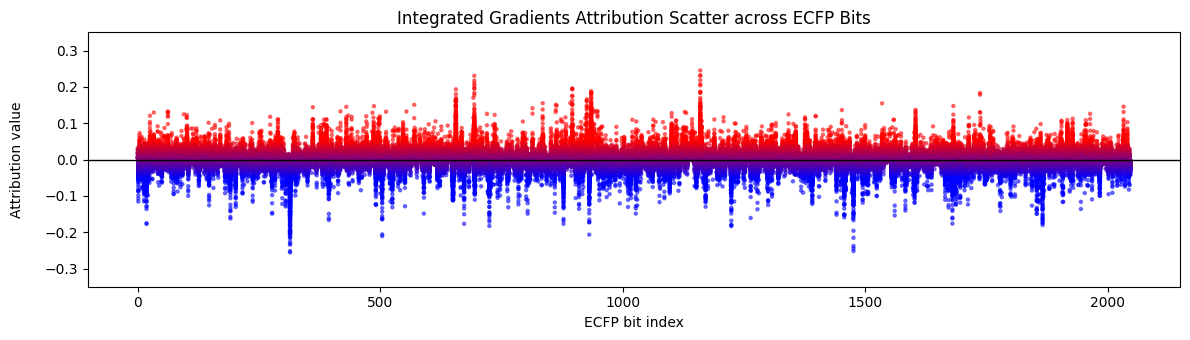

In [87]:
# ============================================================
# Scatter plot of IG attribution values across all ECFP bits
# ============================================================

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def plot_ig_scatter_all_bits(ig_long_table, max_points=200000, seed=0):

    df = ig_long_table[['bit', 'ig_raw']].dropna().copy()

    # Randomly sample points if the dataset is too large
    if max_points is not None and len(df) > max_points:
        df = df.sample(n=max_points, random_state=seed)

    x = df['bit'].values
    y = df['ig_raw'].values

    # Define colormap for negative-to-positive attribution
    cmap = LinearSegmentedColormap.from_list(
        "blue_purple_red", ["blue", "red"]
    )

    # Set a symmetric color normalization range around zero
    vlim = 0.05
    norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

    plt.figure(figsize=(12, 3.5))
    plt.scatter(
        x, y,
        c=y,
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.5
    )

    # Add reference line at zero attribution
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("ECFP bit index")
    plt.ylabel("Attribution value", labelpad=15)
    plt.title("Integrated Gradients Attribution Scatter across ECFP Bits")

    # Set plotting range
    #plt.xlim(0, 2047)
    plt.ylim(-0.35, 0.35)
    plt.tight_layout()

    plt.savefig("Global_IG_scatter.png", dpi=600, bbox_inches="tight")
    plt.show()

plot_ig_scatter_all_bits(ig_long_table)

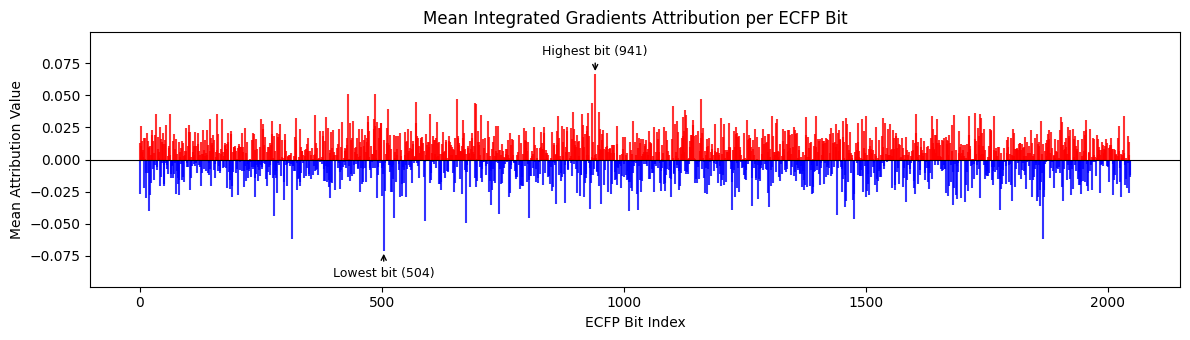

In [88]:
# ============================================================
# Mean IG attribution across ECFP bits
# ============================================================

# Sort by ECFP bit index
bit_stats_sorted = bit_stats.sort_values("bit")

mean_ig_vector = bit_stats_sorted["mean_ig"].values
x = np.arange(len(mean_ig_vector))

plt.figure(figsize=(12, 3.5))

# Identify positive, negative, and zero mean attribution values
pos_idx = mean_ig_vector > 0
neg_idx = mean_ig_vector < 0
zero_idx = mean_ig_vector == 0

# Positive attribution
plt.vlines(x[pos_idx], 0, mean_ig_vector[pos_idx],
           color='red', alpha=0.8, linewidth=1.5)

# Negative attribution
plt.vlines(x[neg_idx], 0, mean_ig_vector[neg_idx],
           color='blue', alpha=0.8, linewidth=1.5)

# Zero attribution
plt.scatter(x[zero_idx],
            np.zeros_like(x[zero_idx]),
            color='#6A0DAD', s=2, alpha=0.6)

plt.axhline(0, color='black', linewidth=0.8)

# ------------------------------------------------------------
# Identify the highest and lowest mean-attribution bits
# ------------------------------------------------------------
max_idx = np.argmax(mean_ig_vector)
min_idx = np.argmin(mean_ig_vector)

max_val = mean_ig_vector[max_idx]
min_val = mean_ig_vector[min_idx]

# Annotate the highest-attribution bit
plt.annotate(f"Highest bit ({max_idx})",
             xy=(max_idx, max_val),
             xytext=(max_idx, max_val + 0.015),
             arrowprops=dict(arrowstyle="->", color="black"),
             ha='center',
             fontsize=9)

# Annotate the lowest-attribution bit
plt.annotate(f"Lowest bit ({min_idx})",
             xy=(min_idx, min_val),
             xytext=(min_idx, min_val - 0.02),
             arrowprops=dict(arrowstyle="->", color="black"),
             ha='center',
             fontsize=9)

plt.title("Mean Integrated Gradients Attribution per ECFP Bit")
plt.xlabel("ECFP Bit Index")
plt.ylabel("Mean Attribution Value")
plt.ylim(-0.099, 0.099)
plt.tight_layout()

plt.savefig("Global_meanIG_bar_point.png", dpi=600, bbox_inches="tight")
plt.show()

In [89]:
# Rank ECFP bits by mean IG attribution
bit_stats_sorted_by_mean = bit_stats.sort_values(
    by="mean_ig",
    ascending=False
).reset_index(drop=True)

display(bit_stats_sorted_by_mean)

,bit,freq,mean_ig,mean_abs,std_ig,pos_count,neg_count,pos_rate,neg_rate
0,941,76,0.066715,0.066715,0.037363,76,0,1.0,0.0
1,487,111,0.051312,0.051312,0.029858,111,0,1.0,0.0
2,430,141,0.050759,0.050759,0.027772,141,0,1.0,0.0
3,1160,1592,0.047412,0.047412,0.030562,1592,0,1.0,0.0
4,656,1041,0.047248,0.047248,0.033962,1041,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
2043,590,110,-0.047838,0.047838,0.029035,0,110,0.0,1.0
2044,673,249,-0.049249,0.049249,0.031271,0,249,0.0,1.0
2045,314,1620,-0.061774,0.061774,0.044677,0,1620,0.0,1.0
2046,1866,379,-0.062084,0.062084,0.041813,0,379,0.0,1.0


[Bit 941] Number of molecules containing this bit: 76
Molecule IDs (first 50): [70, 202, 284, 584, 1123, 1163, 1165, 1171, 1474, 1726, 1782, 2100, 2744, 2925, 3053, 3514, 3515, 3516, 3517, 3518, 3519, 3523, 3524, 3525, 3526, 3527, 3528, 3529, 3530, 3531, 3532, 3533, 3534, 3535, 3536, 3537, 3538, 3539, 3540, 3541, 3542, 3545, 3546, 3547, 3548, 3549, 3550, 3562, 3621, 3635]


,mol_id,y_true,bit,ig_raw,ig_abs,ig_direction,SMILES
71,5426,1,941,0.203676,0.203676,1,CCN(CC)c1ccc(-c2oc3ccccc3c(=O)c2OC)cc1
10,1782,0,941,0.192315,0.192315,1,O=c1c2ccccc2c2cc3nc4ccccc4c(=O)n3c3cccc1c23
35,3537,1,941,0.136784,0.136784,1,CCc1coc2cc(O)ccc2c1=O
72,5427,1,941,0.134424,0.134424,1,CCN(CC)c1ccc2cc(-c3oc4ccccc4c(=O)c3OC)oc2c1
52,4138,1,941,0.130492,0.130492,1,CCNc1c2ccc(=[N+](CC)CC)cc-2oc2cc(N(CC)CC)ccc12
...,...,...,...,...,...,...,...
5,1163,0,941,0.021327,0.021327,1,C=C(Nc1ccc2c(c1)C=C(S(=O)(=O)[O][Na])/C(=N/Nc1cc(C)c(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)cc1C)C2=O)Nc1ccc2c(O)cc(S(=O)(=O)[O][Na])cc2c1
61,4772,1,941,0.021222,0.021222,1,O=C(COc1ccc(/C=C/c2ccc3n2[B-](F)(F)[N+]2=C(c4cccs4)C=CC2=C3)cc1)NCCCCCC(=O)N1C(=O)CCC1=O
12,2744,1,941,0.018258,0.018258,1,Cc1cc(/C=C/c2cc(F)cc(C(F)(F)F)c2)n2c1C=C1C=CC=[N+]1[B-]2(F)F
63,4777,1,941,0.018219,0.018219,1,O=C(COc1ccc(-c2ccc3n2[B-](F)(F)[N+]2=C(c4cccs4)C=CC2=C3)cc1)NCCCCCC(=O)ON1C(=O)CCC1=O


Visualizing the top 35 molecules.


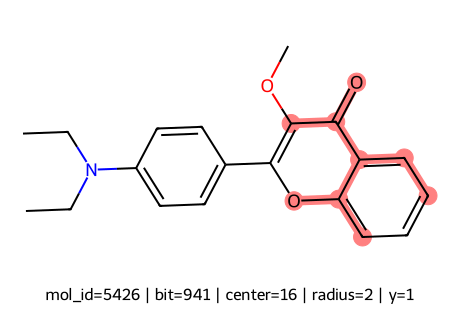

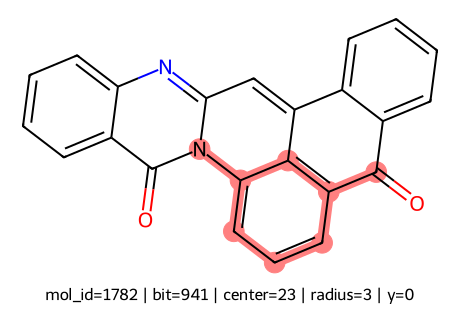

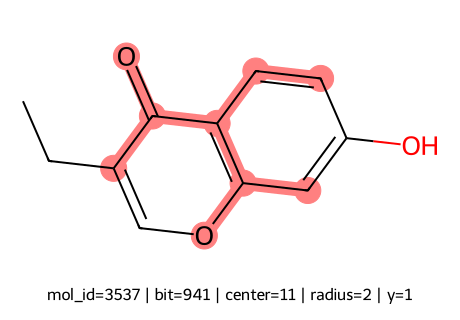

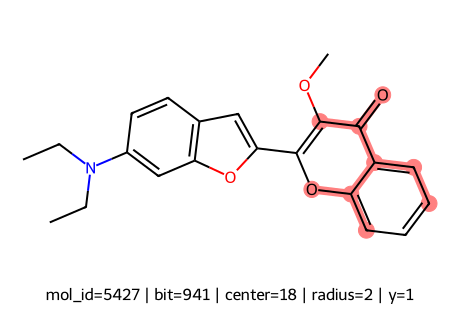

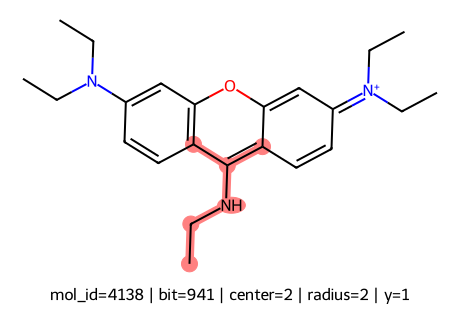

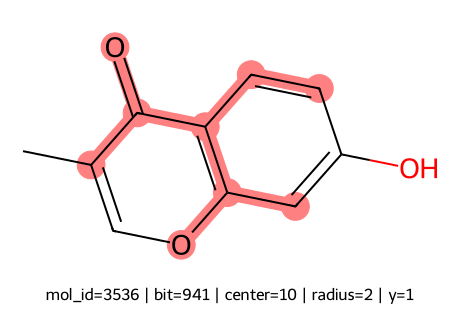

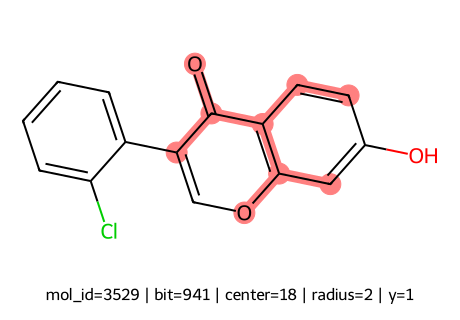

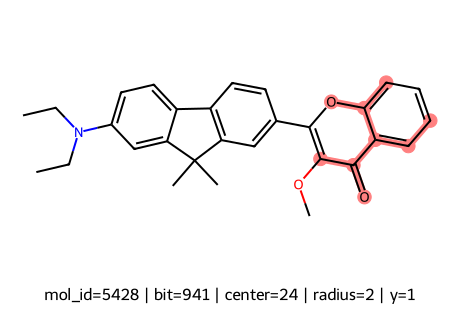

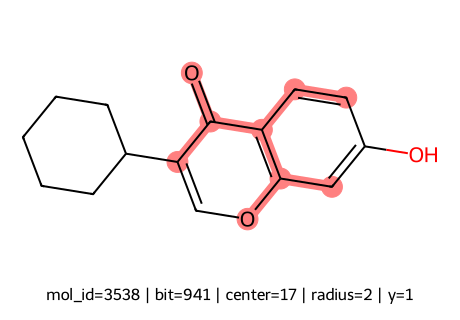

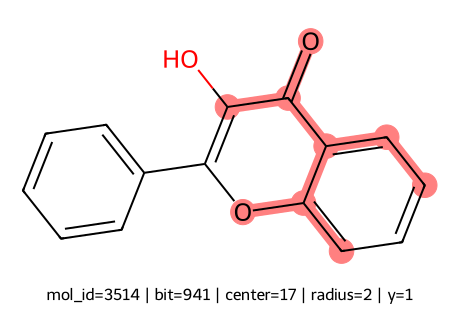

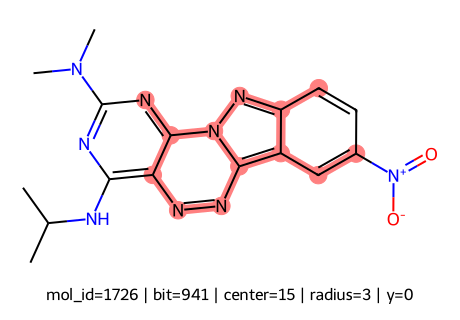

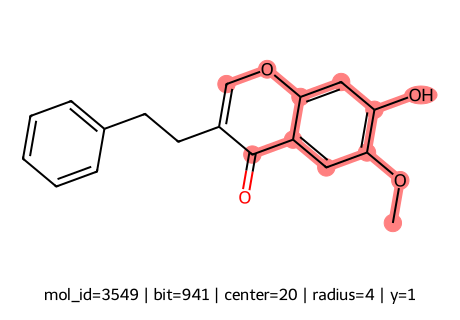

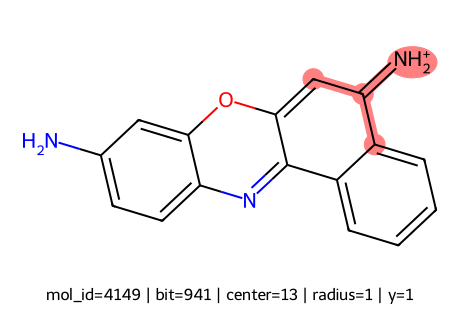

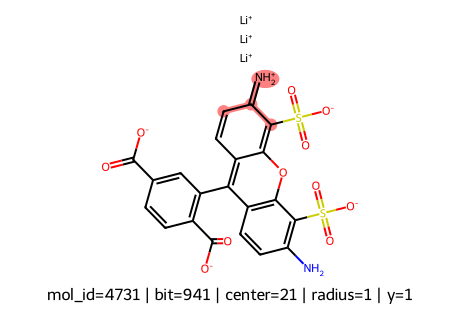

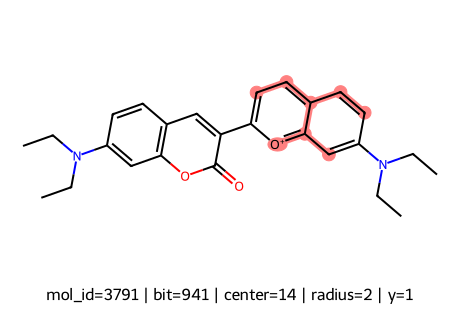

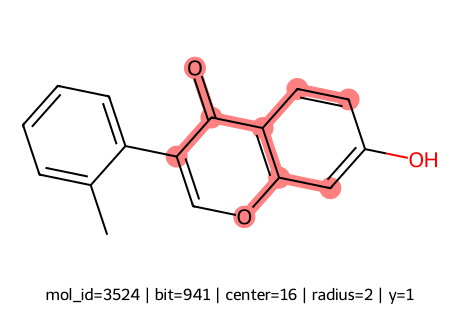

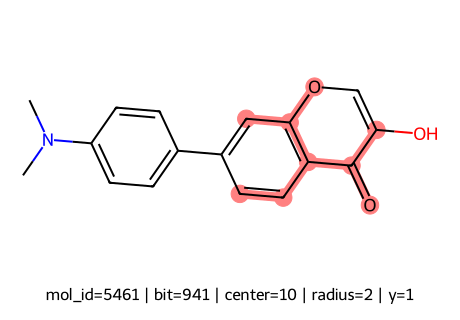

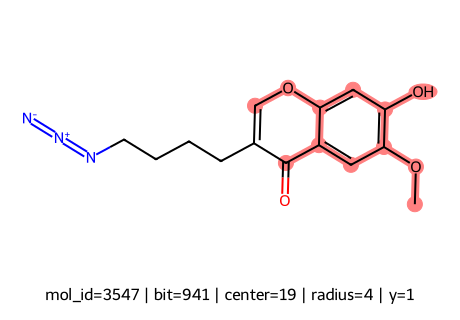

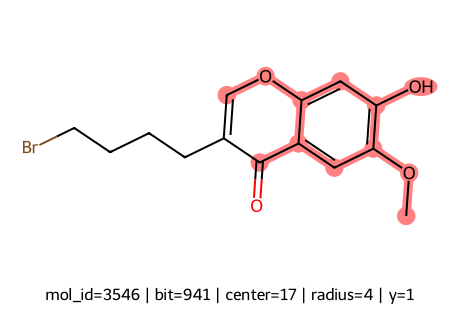

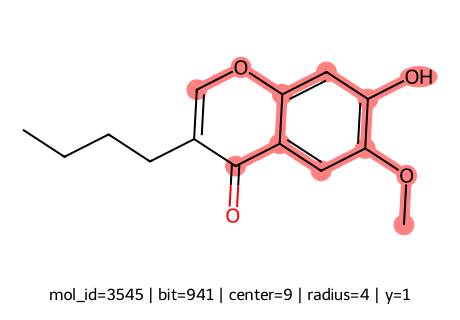

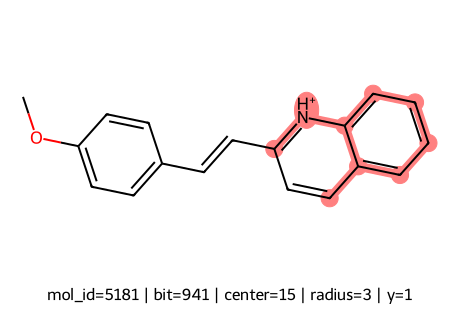

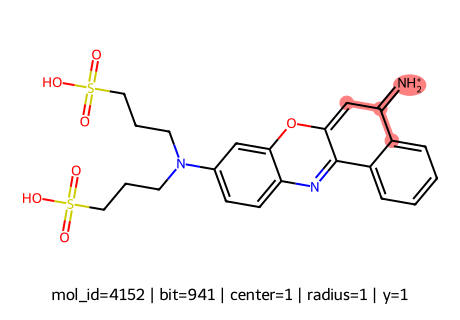

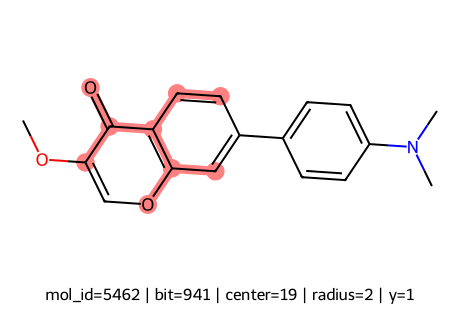

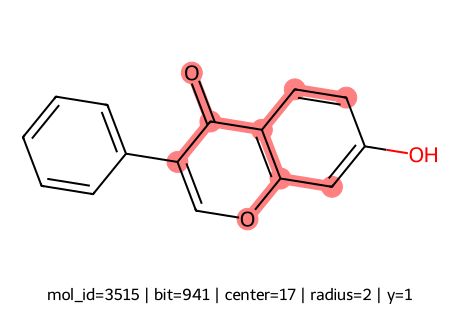

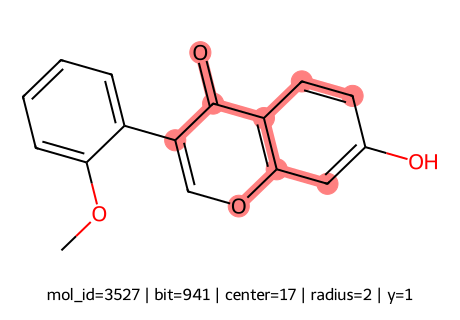

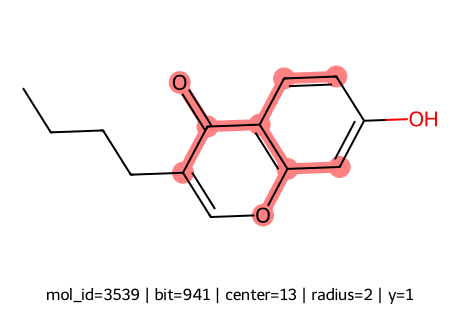

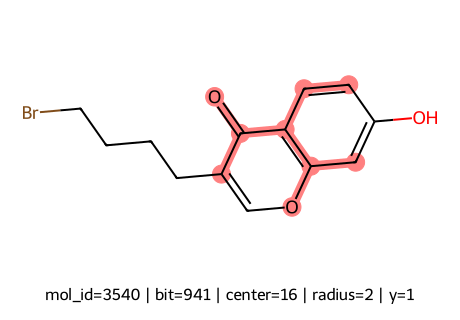

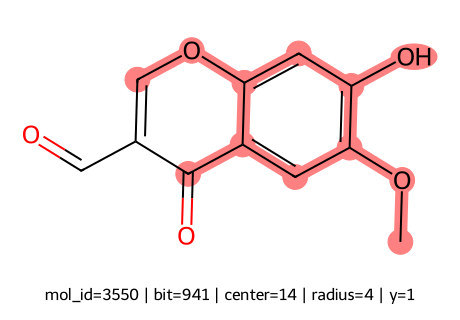

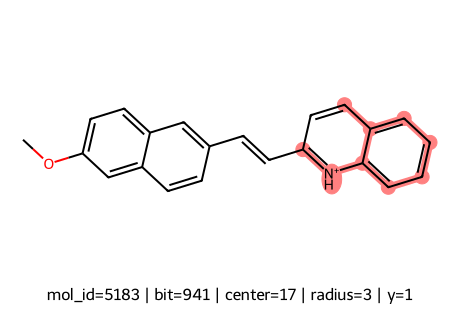

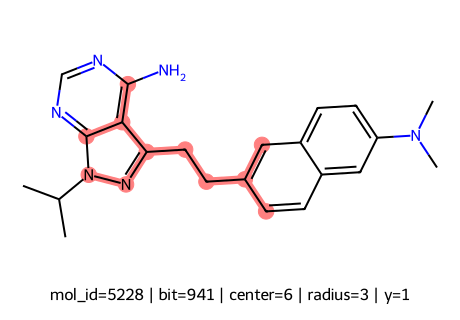

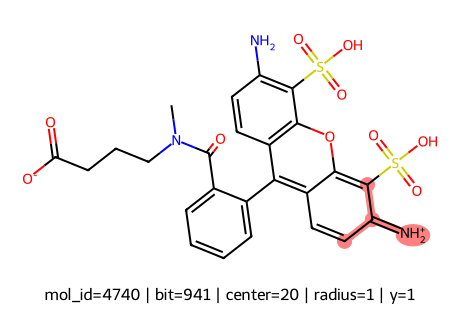

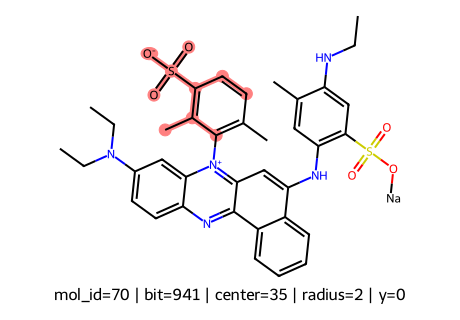

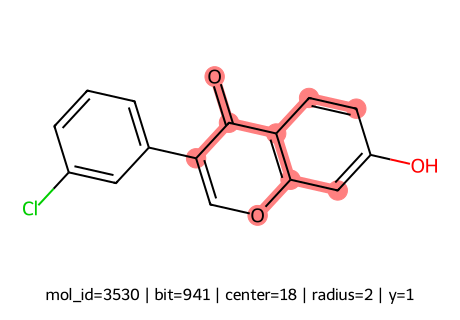

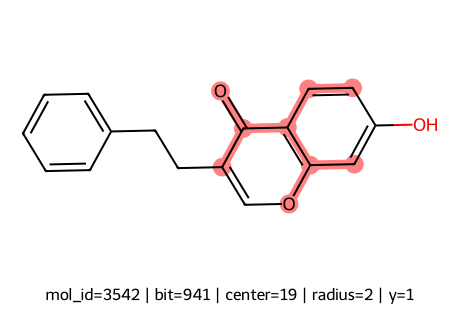

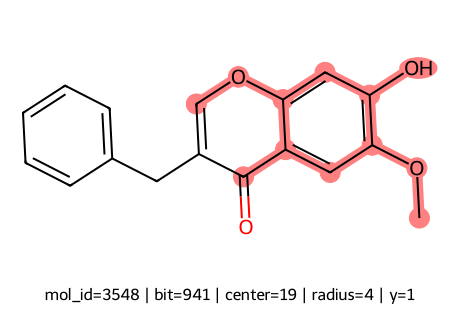

Total number of rendered images: 35


In [90]:
# Visualize molecules containing a selected ECFP bit

bit_id = 941     # Highest positive contribution: contribution of fluorescence prediction

summary_df, mol_ids_all = visualize_bit_across_all_mols(
    bit=bit_id,
    mol_table=mol_table,
    ig_long_table=ig_long_table,
    radius=4,
    n_bits=2048,
    max_draw=35,
    show_all_occurrences=False,
    sort_by="ig_raw"
)

[Bit 314] Number of molecules containing this bit: 1620
Molecule IDs (first 50): [0, 1, 2, 4, 6, 8, 9, 11, 14, 15, 16, 18, 19, 20, 26, 27, 29, 33, 34, 41, 42, 43, 45, 46, 48, 49, 51, 61, 72, 73, 74, 75, 76, 79, 80, 81, 82, 85, 92, 93, 95, 100, 102, 104, 105, 106, 108, 109, 111, 112]


,mol_id,y_true,bit,ig_raw,ig_abs,ig_direction,SMILES
1553,4980,1,314,-0.017733,0.017733,-1,CC1=C2CCCCCCC2C(c2ccc(CNC(=O)c3ccn4c5c(c(-c6ccccc6)c4c3)CN(CCCNC(=O)OC(C)(C)C)C5=O)cc2)=NN1
538,1134,0,314,-0.017788,0.017788,-1,Cc1cc(S(=O)(=O)[O][Na])ccc1/N=N/c1ccc(N/N=C2\C(=O)c3ccc(NC(=O)c4ccc(N)cc4)cc3C=C2S(=O)(=O)[O][Na])c(C)c1
450,932,0,314,-0.018010,0.018010,-1,O=C1/C(=N\Nc2ccc(/N=N/c3ccc(/N=N\c4cc(S(=O)(=O)[O][Na])c5cccc(S(=O)(=O)[O][Na])c5c4)c4ccccc34)c3ccc(S(=O)(=O)[O][Na])cc23)C(S(=O)(=O)[O][Na])=Cc2cc(Nc3ccccc3)ccc21
455,937,0,314,-0.018126,0.018126,-1,O=C1/C(=N\Nc2ccc(/N=N/c3ccc(/N=N\c4cccc(S(=O)(=O)[O][Na])c4)c4cc(S(=O)(=O)[O][Na])ccc34)c3cc(S(=O)(=O)[O][Na])ccc23)C(S(=O)(=O)[O][Na])=Cc2cc(Nc3ccccc3)ccc21
1558,4985,1,314,-0.018154,0.018154,-1,CCN(CC)c1ccc(-c2c3c(n4ccc(C(=O)NCc5ccc(C6=NNC(C)=C7CCCCCCC67)cc5)cc24)C(=O)N(CCCNC(=O)OC(C)(C)C)C3)cc1
...,...,...,...,...,...,...,...
1529,4825,1,314,-0.248989,0.248989,-1,O=c1nc(-c2ccc(S(=O)(=O)Nc3ccc(O)c(Cl)c3)cc2)c2c(=O)nc(-c3ccccc3)c1=2
1531,4827,1,314,-0.251874,0.251874,-1,O=C(O)c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(Br)c(O)c(Br)cc12
991,2269,0,314,-0.251874,0.251874,-1,O=C(O)c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(Br)c(O)c(Br)cc12
1008,2302,0,314,-0.255735,0.255735,-1,O=C1C(=C2C=Cc3ccccc3N2)C(=O)c2c(Cl)c(Cl)c(Cl)c(Cl)c21


Visualizing the top 35 molecules.


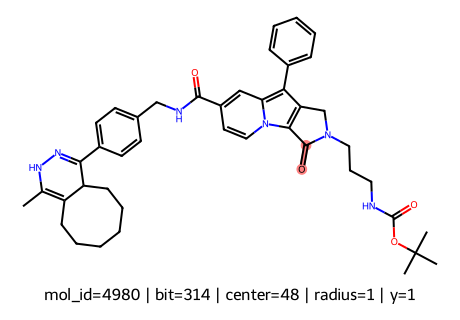

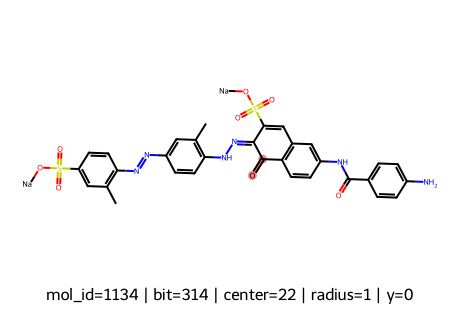

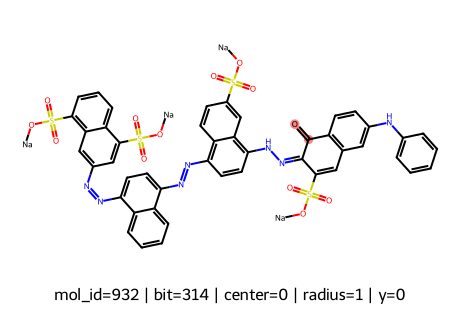

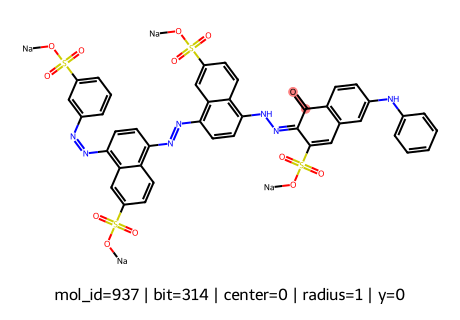

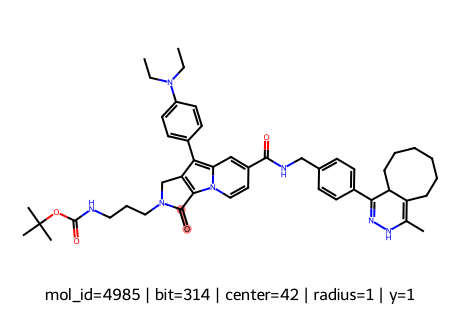

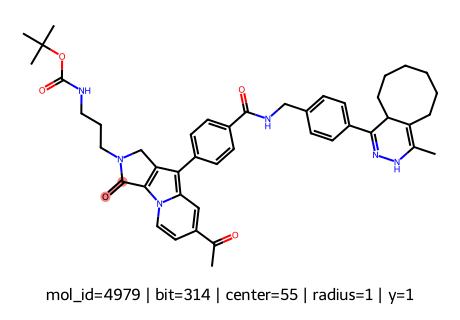

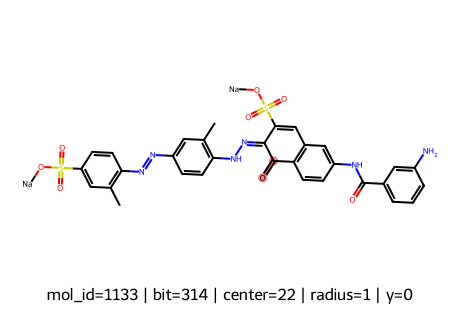

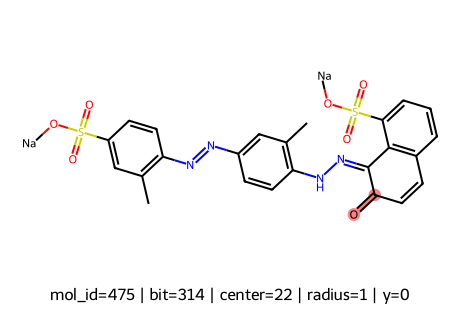

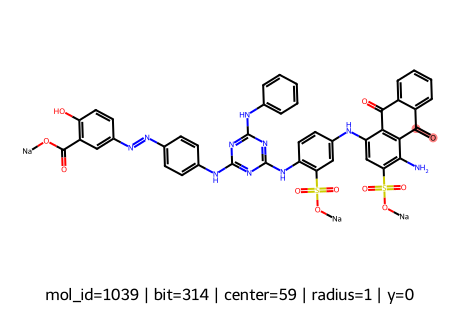

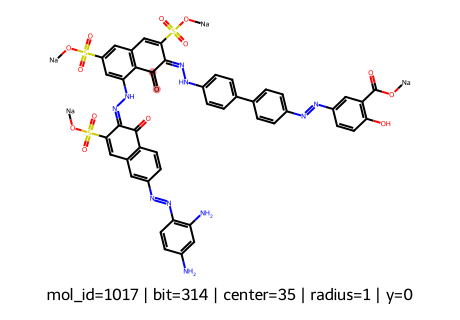

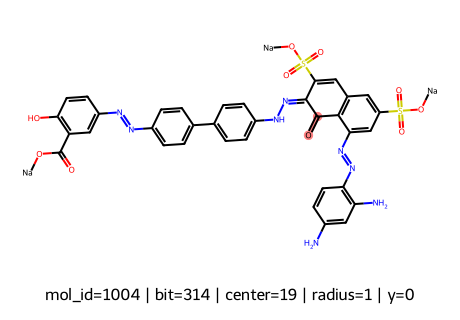

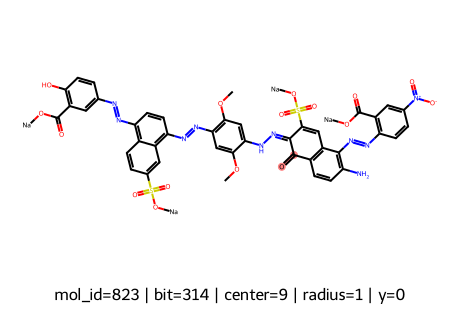

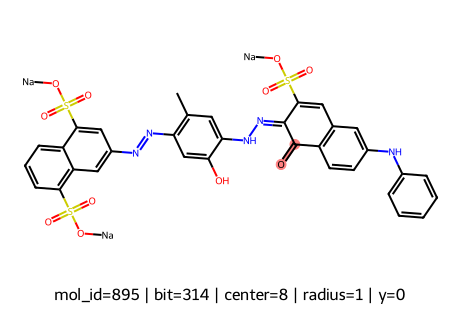

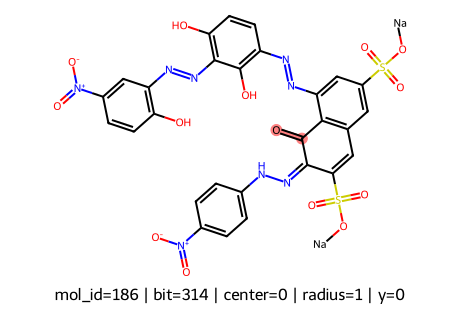

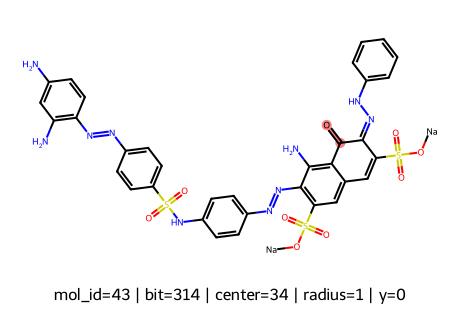

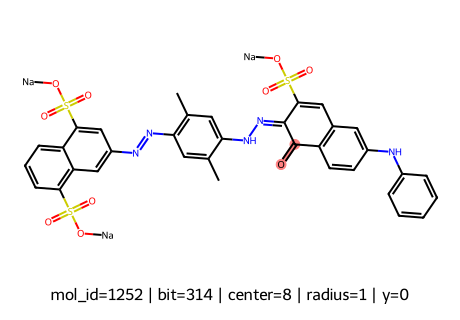

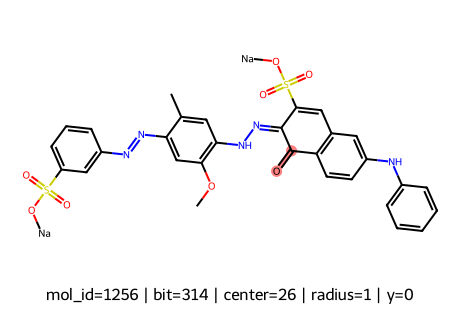

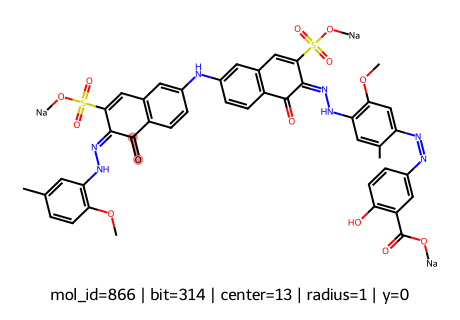

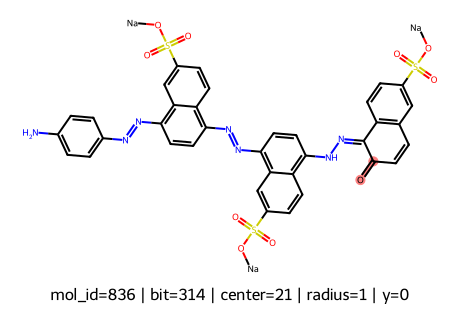

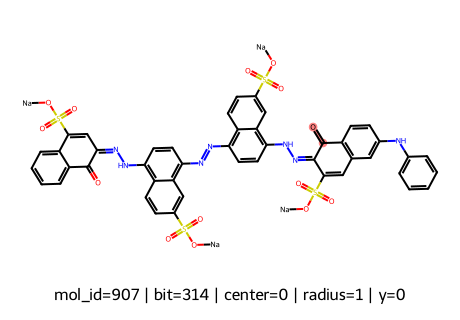

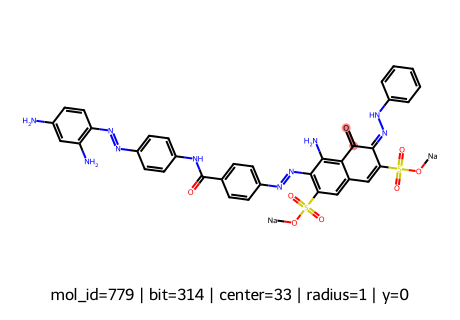

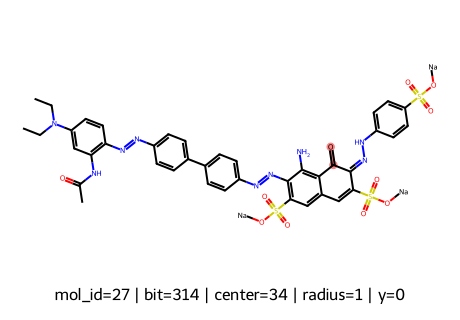

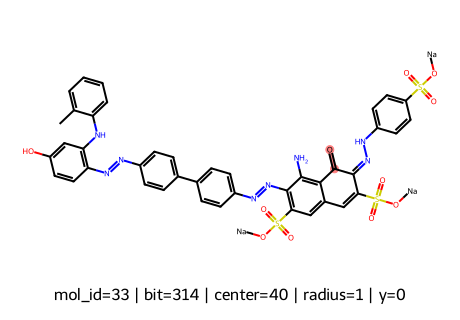

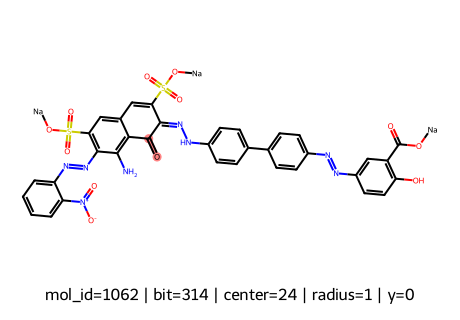

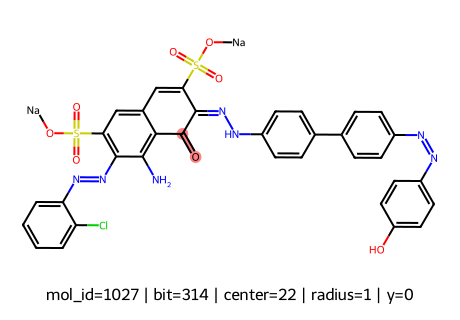

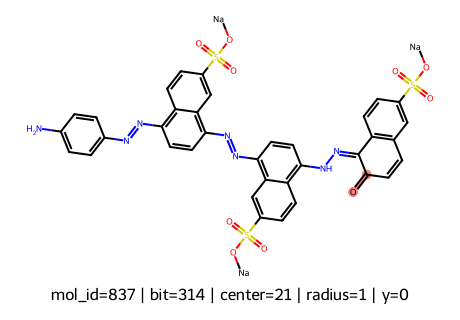

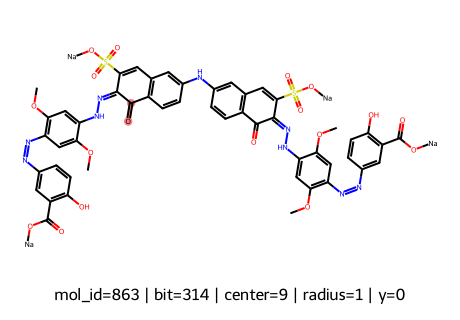

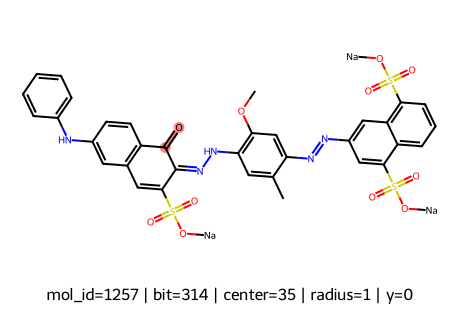

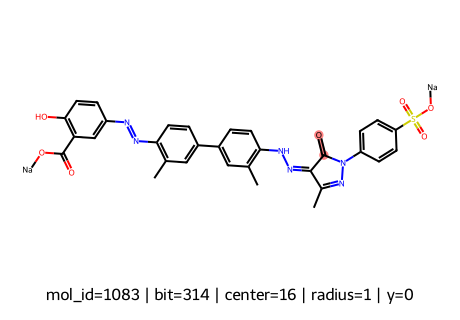

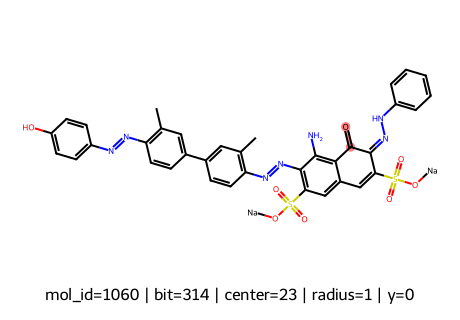

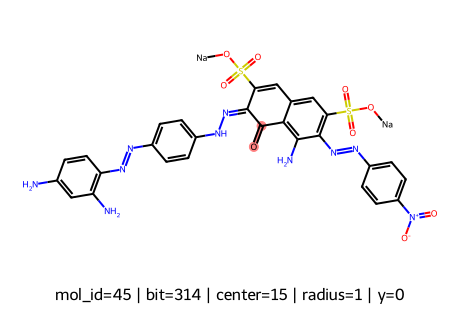

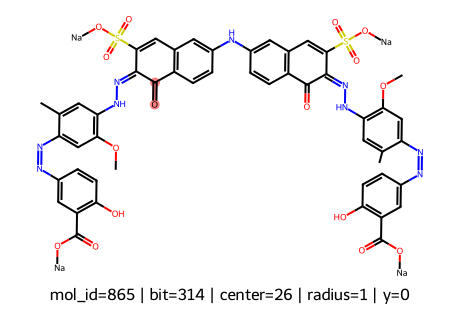

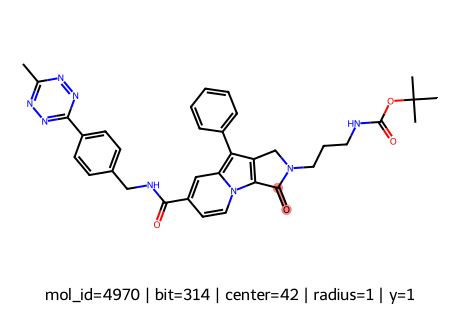

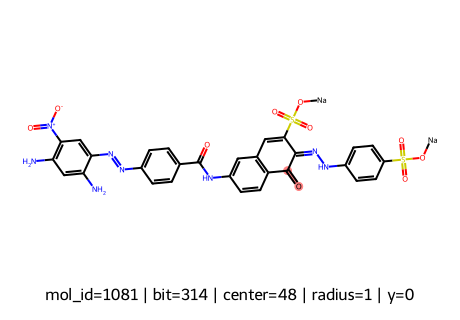

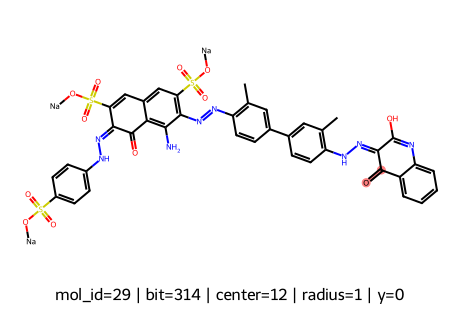

Total number of rendered images: 35


In [91]:
# Visualize molecules containing a selected ECFP bit

bit_id = 314     # Lowest negative contribution: non-fluorescence prediction contribution

summary_df, mol_ids_all = visualize_bit_across_all_mols(
    bit=bit_id,
    mol_table=mol_table,
    ig_long_table=ig_long_table,
    radius=4,
    n_bits=2048,
    max_draw=35,
    show_all_occurrences=False,
    sort_by="ig_raw"
)